# House Prices：価格差の説明と予測の比較

run_id: `v020-exp-31`。米国住宅取引の観察データを使い、関連の説明と未知物件の価格予測を区別する。Kaggle競技参照: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques 。APIトークンは保存・表示しない。実行はJupyter MCPのみ。

In [1]:
from pathlib import Path
import os, sys, json, hashlib, io, contextlib, inspect, warnings
from datetime import datetime, timezone
from dataclasses import asdict
REPO = Path('/home/nahisaho/GitHub/jupytermind')
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(REPO / 'benchmark/projects')
from ai_data_scientist import project_manager, lifecycle, language_router
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-31-house-prices')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
RUN_ID = 'v020-exp-31'
lifecycle.register_run(RUN_ID, handle.notebook_path)
language = language_router.detect_language('住宅価格の違いを説明する主要な特徴と非線形要因を分析してください。')
phase_log = []
def tracked(label, writing=False):
    @contextlib.contextmanager
    def scope():
        if lifecycle.is_cancel_requested(RUN_ID):
            lifecycle.mark_failed(RUN_ID)
            raise RuntimeError('実行の取消が要求されました。')
        start = lifecycle.mark_write_start if writing else lifecycle.mark_execution_start
        end = lifecycle.mark_write_end if writing else lifecycle.mark_execution_end
        start(RUN_ID)
        phase_log.append({'phase': label, 'event': 'start', 'time': datetime.now(timezone.utc).isoformat()})
        try:
            yield
        except Exception:
            lifecycle.mark_failed(RUN_ID)
            phase_log.append({'phase': label, 'event': 'failed', 'time': datetime.now(timezone.utc).isoformat()})
            raise
        finally:
            end(RUN_ID)
            phase_log.append({'phase': label, 'event': 'end', 'time': datetime.now(timezone.utc).isoformat()})
    return scope()
print('run_id:', RUN_ID, 'language:', language)
print(asdict(lifecycle.get_run_status(RUN_ID)))


run_id: v020-exp-31 language: ja
{'run_id': 'v020-exp-31', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-31-house-prices/notebooks/kaggle-v020-kaggle-exp-31-house-prices.ipynb', 'reason': None}


In [2]:
# Kaggle認証情報やAPI例外本文は表示しない。
api_attempts = []
candidates = []
with tracked('Kaggle認証・公開データ検索'):
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
            candidates = list(api.dataset_list(search='house prices advanced regression techniques'))
        api_attempts.append({'stage': 'authenticate/search', 'status': 'success'})
    except Exception as exc:
        api_attempts.append({'stage': 'authenticate/search', 'status': 'failed', 'error_type': type(exc).__name__})
    print(json.dumps(api_attempts, ensure_ascii=False))
    for candidate in candidates:
        print(candidate.ref, '|', candidate.title)


[{"stage": "authenticate/search", "status": "success"}]
fedesoriano/the-boston-houseprice-data | Boston House Prices-Advanced Regression Techniques
rishitaverma02/house-prices-advanced-regression-techniques | House Prices - Advanced Regression Techniques
bjaton/housepricesadvancedregressiontechniquestrain | house-prices-advanced-regression-techniques-train
anmolkumar/house-price-prediction-challenge | House Price Prediction Challenge
vbmokin/house-prices-feature-engineering | House Prices: Feature Engineering
zeeshanmulla/advance-house-price-predicitons | Advance House Price Predicitons
carlmcbrideellis/house-prices-advanced-regression-solution-file | House Prices: Advanced Regression 'solution' file
bhavyagoyal867/house-prices-advanced-regression-techniques-data | House Prices - Advanced Regression Techniques Data
deepaksethi/housepricesadvancedregressiontechniques | house-prices-advanced-regression-techniques 
fedesoriano/air-quality-data-in-india | Air Quality Data in India (2017 - 

In [3]:
with tracked('公開候補のファイル検証'):
    print('SDK signature:', inspect.signature(KaggleApi.dataset_list))
    file_candidates = {}
    for candidate in candidates[:6]:
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                listing = api.dataset_list_files(candidate.ref)
            names = [f.name for f in listing.files]
            file_candidates[candidate.ref] = names
            print(candidate.ref, names)
        except Exception as exc:
            print({'ref': candidate.ref, 'error_type': type(exc).__name__})
    if not candidates:
        paper_path = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
        if paper_path.exists():
            lines = paper_path.read_text(encoding='utf-8').splitlines()
            for i, line in enumerate(lines):
                if 'house' in line.lower() and ('price' in line.lower() or '価格' in line):
                    print('white-paper line', i+1, '\n'.join(lines[max(0,i-2):i+5]))
        else:
            print('取得失敗: 指定white-paper.mdは存在しません。')


SDK signature: (self, sort_by: Optional[str] = None, size: Optional[str] = None, file_type: Optional[str] = None, license_name: Optional[str] = None, tag_ids: Optional[str] = None, search: Optional[str] = None, user: Optional[str] = None, mine: Optional[bool] = False, page: Optional[int] = 1, max_size: Optional[str] = None, min_size: Optional[str] = None) -> list[kagglesdk.datasets.types.dataset_api_service.ApiDataset | None] | None
fedesoriano/the-boston-houseprice-data ['boston.csv']
rishitaverma02/house-prices-advanced-regression-techniques ['data_description.txt', 'sample_submission.csv', 'test (1).csv', 'train (1).csv']
bjaton/housepricesadvancedregressiontechniquestrain ['train.csv']
anmolkumar/house-price-prediction-challenge ['sample_submission.csv', 'test.csv', 'train.csv']
vbmokin/house-prices-feature-engineering ['feature_score_sort.csv', 'feature_score_sort_new.csv']
zeeshanmulla/advance-house-price-predicitons ['data description.txt', 'formulatedtest.csv', 'sample_submissi

## 取得元・対応性の確認

Bostonデータや加工済み特徴量は採用しない。競技と同名で学習・テスト・辞書を含む公開ミラーを選択し、行列サイズ・主要列・Id・価格値を検証する。これは対応性の確認であり、公式原本との暗号学的同一性の証明ではない。

In [6]:
import zipfile
from urllib.parse import unquote
import pandas as pd
import numpy as np
from IPython.display import display
from ai_data_scientist import ingestion
SLUG = 'rishitaverma02/house-prices-advanced-regression-techniques'
FILES = ['train (1).csv', 'test (1).csv', 'data_description.txt']
provenance = []
with tracked('Kaggle公開対応データ取得'):
    if SLUG not in file_candidates or not set(FILES).issubset(file_candidates[SLUG]):
        raise RuntimeError('同一競技に対応する候補ファイルを確認できません。別データへの置換は禁止。')
    for filename in FILES:
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                api.dataset_download_file(SLUG, filename, path=str(data_dir), force=True, quiet=True)
        except Exception as exc:
            print({'stage': 'download', 'filename': filename, 'error_type': type(exc).__name__})
            raise RuntimeError('Kaggle取得失敗。指定稿に同一CSVが明示された場合のみフォールバック可能。') from None
        destination = data_dir / filename
        encoded_matches = [p for p in data_dir.iterdir() if p.name != filename and unquote(p.name) == filename]
        if len(encoded_matches) > 1:
            raise RuntimeError('取得されたURLエンコード名を一意に確認できません。')
        if len(encoded_matches) == 1:
            encoded_matches[0].replace(destination)
        if not destination.exists():
            compressed = data_dir / (filename + '.zip')
            if not compressed.exists():
                raise FileNotFoundError('SDKの取得ファイルが見つかりません。')
            with zipfile.ZipFile(compressed) as archive:
                matching = [n for n in archive.namelist() if Path(n).name == filename]
                if len(matching) != 1:
                    raise RuntimeError('ZIP内の対応ファイルを一意に確認できません。')
                destination.write_bytes(archive.read(matching[0]))
        provenance.append({'owner_dataset_slug': SLUG, 'filename': filename,
            'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
            'sha256': hashlib.sha256(destination.read_bytes()).hexdigest(),
            'source': 'Kaggle Python SDK dataset_download_file'})
    df = ingestion.ingest(ingestion.SourceSpec('csv', str(data_dir / FILES[0])), row_limit=10000).dataframe
    test_df = ingestion.ingest(ingestion.SourceSpec('csv', str(data_dir / FILES[1])), row_limit=10000).dataframe
    dictionary = (data_dir / 'data_description.txt').read_text(encoding='utf-8-sig')
    required = {'Id','SalePrice','OverallQual','GrLivArea','Neighborhood','YearBuilt','GarageCars','TotalBsmtSF'}
    assert df.shape == (1460,81) and test_df.shape == (1459,80)
    assert required.issubset(df.columns) and df.Id.tolist() == list(range(1,1461))
    assert df.SalePrice.iloc[0] == 208500 and df.SalePrice.iloc[1] == 181500
    assert 'GrLivArea' in dictionary and 'Neighborhood' in dictionary
    print('同一性チェック: 1460×81 / 1459×80、連続Id、先頭価格、主要列・辞書の一致。公式CSVとのバイト同一性は未確認。')
    display(pd.DataFrame(provenance))
    print('辞書抜粋（意味の確認）:')
    for field in ['SalePrice','OverallQual','GrLivArea','LotArea','Neighborhood','YearBuilt','YearRemodAdd','GarageCars','TotalBsmtSF','PoolQC','Alley','BsmtQual','MSSubClass','SaleCondition']:
        pos = dictionary.find(field + ':')
        if pos >= 0:
            stop = dictionary.find('\n\n', pos)
            print(dictionary[pos:stop if stop >= 0 else pos+400][:1200])


同一性チェック: 1460×81 / 1459×80、連続Id、先頭価格、主要列・辞書の一致。公式CSVとのバイト同一性は未確認。
辞書抜粋（意味の確認）:
OverallQual: Rates the overall material and finish of the house
GrLivArea: Above grade (ground) living area square feet
LotArea: Lot size in square feet
Neighborhood: Physical locations within Ames city limits
YearBuilt: Original construction date
YearRemodAdd: Remodel date (same as construction date if no remodeling or additions)
GarageCars: Size of garage in car capacity
TotalBsmtSF: Total square feet of basement area
PoolQC: Pool quality
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       NA	No Pool
		
Fence: Fence quality
		
       GdPrv	Good Privacy
       MnPrv	Minimum Privacy
       GdWo	Good Wood
       MnWw	Minimum Wood/Wire
       NA	No Fence
	
MiscFeature: Miscellaneous feature not covered in other categories
		
       Elev	Elevator
       Gar2	2nd Garage (if not described in garage section)
       Othr	Other
       Shed	Shed (over 100 SF)
       TenC	Tennis Court

,owner_dataset_slug,filename,retrieved_at_utc,sha256,source
0,rishitaverma02/house-prices-advanced-regressio...,train (1).csv,2026-10-01T21:31:07.280211+00:00,1e18addf81e5e4d347cc17ee6075bbe4a42b7fa26b9e5b...,Kaggle Python SDK dataset_download_file
1,rishitaverma02/house-prices-advanced-regressio...,test (1).csv,2026-10-01T21:31:09.580967+00:00,8fdd3d829d4d986b58f845c9553b225e67dd8383624d90...,Kaggle Python SDK dataset_download_file
2,rishitaverma02/house-prices-advanced-regressio...,data_description.txt,2026-10-01T21:31:10.182281+00:00,356a4670aa688afa8ba44b1365b633fbbac2dae535fe46...,Kaggle Python SDK dataset_download_file


## データ定義・前提・意味的異常

NAを一律に行削除しない。構造的な設備なしと未知欠損は辞書・数量列との整合で確認する。価格単位は辞書に記載がなければ推定とし、因果効果は対象外とする。

In [7]:
import re
from ai_data_scientist import data_definition, analysis_assumptions, data_quality, cleaning, eda, stats_analysis
with tracked('データ定義・意味的品質検査'):
    descriptions = dict(re.findall(r'^([A-Za-z0-9]+):[ \t]*(.*)$', dictionary, flags=re.MULTILINE))
    variables = {}
    for column in df.columns:
        description = descriptions.get(column)
        variables[column] = {'definition': data_definition.FieldValue(description or '辞書で未確認', 'verified' if description else 'unknown', 'data_description.txt')}
        if description and ('square feet' in description.lower() or 'square foot' in description.lower()):
            variables[column]['unit'] = data_definition.FieldValue('square feet', 'verified', 'data_description.txt')
    variables['Id']['definition'] = data_definition.FieldValue('行の識別子（連続番号）', 'inferred', '実測値')
    variables['SalePrice'] = {'definition': data_definition.FieldValue('住宅売却価格（目的変数）', 'inferred', '競技名・列名・値'),
        'unit': data_definition.FieldValue('米ドルと推定。取得辞書にSalePriceの単位記載なし', 'inferred', 'Ames所在地と価格値')}
    definition_manifest = data_definition.build_manifest(
        source={'slug':data_definition.FieldValue(SLUG,'verified','Kaggle SDK'),
            'files': data_definition.FieldValue(provenance,'verified','取得バイトのSHA-256'),
            'license': data_definition.FieldValue(None,'unknown','利用条件の正式確認は未実施')},
        dataset_scope={'location': data_definition.FieldValue('Ames city limits','verified','Neighborhood定義'),
            'years': data_definition.FieldValue(sorted(df.YrSold.unique().tolist()),'verified','取得データ'),
            'population_representativeness':data_definition.FieldValue('全米・現在価格への代表性は不明','unknown')},
        variables=variables,
        transformations=('Idを予測から除外','MSSubClassを名義尺度に変換','log(SalePrice)','学習fold内中央値補完・欠損指標・OneHot'))
    print('取得メタデータ（省略なし）:', json.dumps(provenance, ensure_ascii=False, indent=2))
    print('データ定義manifest:', json.dumps(asdict(definition_manifest), ensure_ascii=False, indent=2))
    print('未解決フィールド:', [(p,asdict(v)) for p,v in definition_manifest.unresolved_fields()])
    print('inferredフィールド:', [(c,k,asdict(v)) for c,fields in variables.items() for k,v in fields.items() if v.status=='inferred'])
    schema = {'Id':{'not_null':True,'unique':True,'min':1},'SalePrice':{'not_null':True,'min':1},
        'OverallQual':{'min':1,'max':10,'not_null':True},'OverallCond':{'min':1,'max':10},
        'GrLivArea':{'min':1},'LotArea':{'min':1},'GarageCars':{'min':0,'max':5},
        'TotalBsmtSF':{'min':0},'YearBuilt':{'min':1800,'max':2010},'YrSold':{'allowed':[2006,2007,2008,2009,2010]},
        'SaleCondition':{'allowed':['Normal','Abnorml','AdjLand','Alloca','Family','Partial']}}
    anomalies = data_quality.detect_anomalies(df,schema)
    print('宣言的意味異常:', [asdict(a) for a in anomalies])
    cross_checks = pd.DataFrame({'construction_after_sale':df.YearBuilt>df.YrSold,
        'remodel_after_sale':df.YearRemodAdd>df.YrSold,'garage_after_sale':df.GarageYrBlt>df.YrSold,
        'living_area_component_mismatch':df.GrLivArea != df['1stFlrSF']+df['2ndFlrSF']+df.LowQualFinSF,
        'basement_component_mismatch':df.TotalBsmtSF != df.BsmtFinSF1+df.BsmtFinSF2+df.BsmtUnfSF,
        'garage_quality_missing_with_capacity':df.GarageQual.isna() & (df.GarageCars>0),
        'basement_quality_missing_with_area':df.BsmtQual.isna() & (df.TotalBsmtSF>0),
        'pool_quality_missing_with_area':df.PoolQC.isna() & (df.PoolArea>0)})
    display(cross_checks.sum().rename('件数').to_frame())
    display(df.loc[cross_checks.any(axis=1), ['Id','YrSold','YearBuilt','YearRemodAdd','GarageYrBlt','SalePrice']])
    clean_result = cleaning.clean_dataset(df, operation='drop_duplicates')
    print('重複処理結果:', clean_result)
    eda_report = eda.explore(df, top_n=5)
    print('形状:', df.shape, 'カテゴリ列:', len(eda_report.categorical_summary))
    missing_table = pd.DataFrame(eda_report.missing_summary).T.sort_values('missing_ratio',ascending=False)
    display(missing_table[missing_table.missing_count>0])
    print('全カテゴリ要約（ratioは非欠損内の比率）:', json.dumps(eda_report.categorical_summary,ensure_ascii=False,default=str))
    print('MSSubClass（整数コードだが名義尺度）:',df.MSSubClass.value_counts().sort_index().to_dict())
    print('構造的NA対照:', {c:{'missing':int(df[c].isna().sum()),'dictionary_has_NA':bool(re.search(r'NA[ \t]+', dictionary[dictionary.find(c+':'):dictionary.find(c+':')+1200]))} for c in ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu','GarageQual','BsmtQual']})
    display(df.SalePrice.describe(percentiles=[.01,.25,.5,.75,.99]))
    print('価格歪度:',df.SalePrice.skew(),'log価格歪度:',np.log(df.SalePrice).skew())
    corr_rows=[]
    for col in ['OverallQual','GrLivArea','GarageCars','TotalBsmtSF','YearBuilt','LotArea']:
        result=stats_analysis.correlation(df.dropna(subset=[col,'SalePrice']),col,'SalePrice',language='ja')
        corr_rows.append({'feature':col,'Pearson_price':result.statistic,'Spearman_price':df[col].corr(df.SalePrice,method='spearman'),'interpretation':result.interpretation})
    corr_table=pd.DataFrame(corr_rows)
    display(corr_table)
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'target':'観測されたAmes取引の価格関連と同分布の予測','excludes':['因果効果','現在の住宅価格','全国への外挿']},
        assumptions=(
            analysis_assumptions.Assumption('A1','説明変数間の相関を調整しても因果効果とは解釈しない','verified',impact_if_false='交絡により因果解釈が破綻',conclusion_critical=True),
            analysis_assumptions.Assumption('A2','無作為foldは同時期・同地域の未知取引を近似する','assumed',impact_if_false='時期・地域外への性能は過大評価',conclusion_critical=True),
            analysis_assumptions.Assumption('A3','補完・標準化・カテゴリ符号化は各学習fold内で学習する','verified',conclusion_critical=True),
            analysis_assumptions.Assumption('A4','NAが設備なしを表す列と未観測を区別するが曖昧なものは欠損扱い','assumed',impact_if_false='設備効果と記録欠損が混ざる',conclusion_critical=True)),
        causal_scope='associational',sampling={'n':len(df),'seed':31})
    print('分析前提manifest:',json.dumps(asdict(assumption_manifest),ensure_ascii=False,indent=2))
    print('前提検査findings:',[asdict(f) for f in analysis_assumptions.check_manifest(assumption_manifest)])
    print('適用外: validate_anomalies/compare_datasetsは独立参照データなし。競技testは同じ作成過程で価格ラベルもないため独立検証にしない。')


取得メタデータ（省略なし）: [
  {
    "owner_dataset_slug": "rishitaverma02/house-prices-advanced-regression-techniques",
    "filename": "train (1).csv",
    "retrieved_at_utc": "2026-10-01T21:31:07.280211+00:00",
    "sha256": "1e18addf81e5e4d347cc17ee6075bbe4a42b7fa26b9e5b063e8f692a5f929d41",
    "source": "Kaggle Python SDK dataset_download_file"
  },
  {
    "owner_dataset_slug": "rishitaverma02/house-prices-advanced-regression-techniques",
    "filename": "test (1).csv",
    "retrieved_at_utc": "2026-10-01T21:31:09.580967+00:00",
    "sha256": "8fdd3d829d4d986b58f845c9553b225e67dd8383624d90fb6ca1d4bed5798c1e",
    "source": "Kaggle Python SDK dataset_download_file"
  },
  {
    "owner_dataset_slug": "rishitaverma02/house-prices-advanced-regression-techniques",
    "filename": "data_description.txt",
    "retrieved_at_utc": "2026-10-01T21:31:10.182281+00:00",
    "sha256": "356a4670aa688afa8ba44b1365b633fbbac2dae535fe4638532630607d64070d",
    "source": "Kaggle Python SDK dataset_download_file

,件数
construction_after_sale,0
remodel_after_sale,1
garage_after_sale,0
living_area_component_mismatch,0
basement_component_mismatch,0
garage_quality_missing_with_capacity,0
basement_quality_missing_with_area,0
pool_quality_missing_with_area,0


,Id,YrSold,YearBuilt,YearRemodAdd,GarageYrBlt,SalePrice
523,524,2007,2007,2008,2007.0,184750


,missing_count,missing_ratio
PoolQC,1453.0,0.995205
MiscFeature,1406.0,0.963014
Alley,1369.0,0.937671
Fence,1179.0,0.807534
MasVnrType,872.0,0.597260
FireplaceQu,690.0,0.472603
LotFrontage,259.0,0.177397
GarageQual,81.0,0.055479
GarageFinish,81.0,0.055479
GarageType,81.0,0.055479


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
1%        61815.970000
25%      129975.000000
50%      163000.000000
75%      214000.000000
99%      442567.010000
max      755000.000000
Name: SalePrice, dtype: float64

,feature,Pearson_price,Spearman_price,interpretation
0,OverallQual,0.790982,0.809829,相関係数は 0.7910 (p=2.186e-313) で、強い正の相関が見られます。
1,GrLivArea,0.708624,0.731310,相関係数は 0.7086 (p=4.518e-223) で、強い正の相関が見られます。
2,GarageCars,0.640409,0.690711,相関係数は 0.6404 (p=2.499e-169) で、中程度の正の相関が見られます。
3,TotalBsmtSF,0.613581,0.602725,相関係数は 0.6136 (p=9.484e-152) で、中程度の正の相関が見られます。
4,YearBuilt,0.522897,0.652682,相関係数は 0.5229 (p=2.99e-103) で、中程度の正の相関が見られます。
5,LotArea,0.263843,0.456461,相関係数は 0.2638 (p=1.123e-24) で、弱い正の相関が見られます。


## 分布・欠損・カテゴリの探索

品質は順序尺度、地区と住宅種別コードは名義尺度。地区図は標本数20以上に限定し、小標本による極端な中央値を避ける。

注意：この節の欠損図は初回の既定CSV読込みの結果。MasVnrTypeのNoneを欠損扱いしているため真の未観測率ではない。反復1でNone864件を保持し、真のNA8件（0.55%）を確認した。

視覚検査ログ: [{'title': '価格分布', 'missing_glyphs': [], 'bytes': 22610}, {'title': '対数価格と欠損', 'missing_glyphs': [], 'bytes': 74801}, {'title': '面積・品質・地区の価格関連', 'missing_glyphs': [], 'bytes': 199955}]


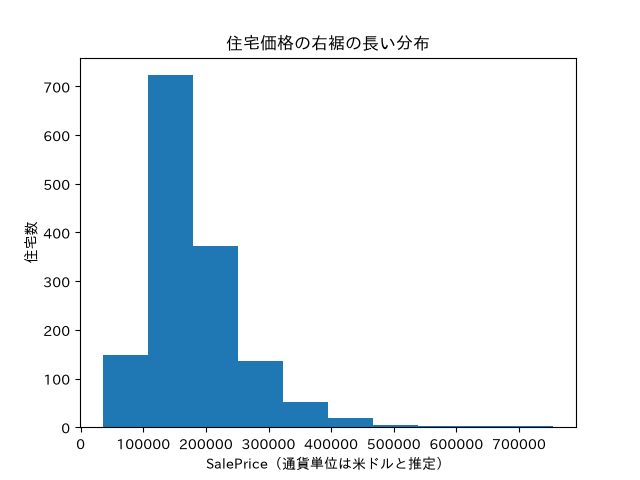

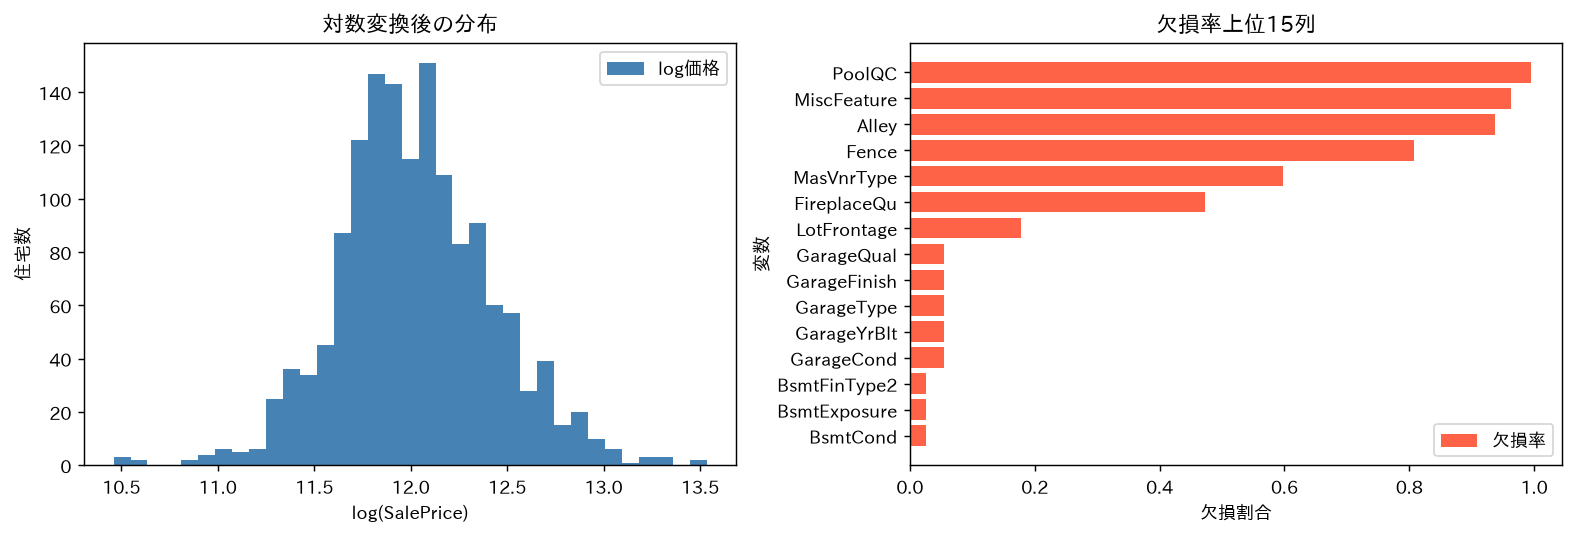

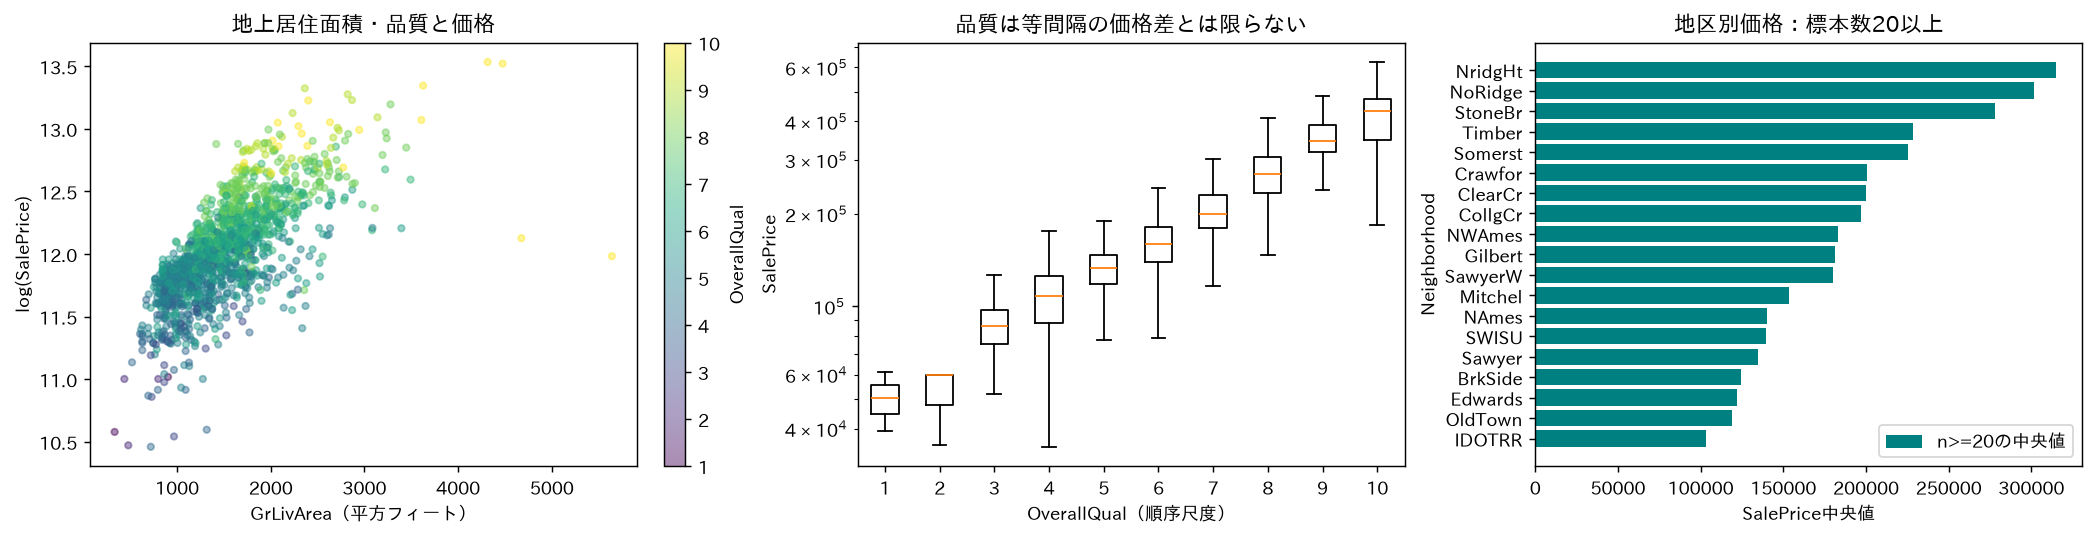

,count,median
Neighborhood,,
IDOTRR,37,103000.0
OldTown,113,119000.0
Edwards,100,121750.0
BrkSide,58,124300.0
Sawyer,74,135000.0
SWISU,25,139500.0
NAmes,225,140000.0
Mitchel,49,153500.0
SawyerW,59,179900.0


In [8]:
import matplotlib.pyplot as plt
from ai_data_scientist import visualization
chart_checks = []
def emit_png(png_bytes, label, missing_glyphs=()):
    output = visualization.build_image_output(png_bytes)
    display(output.data, raw=True)
    chart_checks.append({'title':label,'missing_glyphs':list(missing_glyphs),'bytes':len(png_bytes)})
def emit_figure(fig, label):
    buffer=io.BytesIO()
    with warnings.catch_warnings(record=True) as observed:
        warnings.simplefilter('always')
        fig.savefig(buffer,format='png',dpi=130,bbox_inches='tight')
    missing=[str(w.message) for w in observed if 'Glyph' in str(w.message)]
    plt.close(fig)
    emit_png(buffer.getvalue(),label,missing)
with tracked('探索図表'):
    emit_png(visualization.render_chart(df,kind='hist',x='SalePrice',title='住宅価格の右裾の長い分布',xlabel='SalePrice（通貨単位は米ドルと推定）',ylabel='住宅数'), '価格分布')
    fig,ax=plt.subplots(1,2,figsize=(12,4),layout='constrained')
    ax[0].hist(np.log(df.SalePrice),bins=35,color='steelblue',label='log価格')
    ax[0].set(title='対数変換後の分布',xlabel='log(SalePrice)',ylabel='住宅数'); ax[0].legend()
    show=missing_table[missing_table.missing_count>0].head(15).iloc[::-1]
    ax[1].barh(show.index,show.missing_ratio,color='tomato',label='欠損率')
    ax[1].set(title='欠損率上位15列',xlabel='欠損割合',ylabel='変数'); ax[1].legend()
    emit_figure(fig,'対数価格と欠損')
    fig,ax=plt.subplots(1,3,figsize=(16,4),layout='constrained')
    s=ax[0].scatter(df.GrLivArea,np.log(df.SalePrice),c=df.OverallQual,cmap='viridis',alpha=.45,s=13)
    fig.colorbar(s,ax=ax[0],label='OverallQual')
    ax[0].set(title='地上居住面積・品質と価格',xlabel='GrLivArea（平方フィート）',ylabel='log(SalePrice)')
    qual=[df.loc[df.OverallQual==q,'SalePrice'] for q in sorted(df.OverallQual.unique())]
    ax[1].boxplot(qual,tick_labels=sorted(df.OverallQual.unique()),showfliers=False)
    ax[1].set(title='品質は等間隔の価格差とは限らない',xlabel='OverallQual（順序尺度）',ylabel='SalePrice'); ax[1].set_yscale('log')
    neighborhood=df.groupby('Neighborhood').SalePrice.agg(['count','median']).query('count>=20').sort_values('median')
    ax[2].barh(neighborhood.index,neighborhood['median'],color='teal',label='n>=20の中央値')
    ax[2].set(title='地区別価格：標本数20以上',xlabel='SalePrice中央値',ylabel='Neighborhood'); ax[2].legend()
    emit_figure(fig,'面積・品質・地区の価格関連')
    display(neighborhood)
    print('視覚検査ログ:',chart_checks)


## 予測性能の検証設計

同一の5-fold（seed=31）でOOF予測を作成する。補完・標準化・OneHotは学習foldのみでfitする。生価格Ridge、対数Ridge、5変数の加法スプラインRidge、交互作用を許す勾配ブースティングを固定仕様で比較する。価格尺度のMAE・RMSE・R²と、競技に合わせたlog RMSEを併記する。exp(log予測)は条件付き幾何平均に近く、平均価格の不偏推定ではない。

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone
from threadpoolctl import threadpool_limits
from scipy import stats
X=df.drop(columns=['SalePrice','Id']).copy()
X['MSSubClass']=X.MSSubClass.astype(str)
cat_cols=X.select_dtypes(include=['object','str']).columns.tolist()
num_cols=[c for c in X.columns if c not in cat_cols]
y=df.SalePrice.to_numpy(dtype=float)
log_y=np.log(y)
folds=list(KFold(n_splits=5,shuffle=True,random_state=31).split(X))
def preprocess(columns=None, spline=False):
    chosen=list(X.columns) if columns is None else columns
    cats=[c for c in cat_cols if c in chosen]
    nums=[c for c in num_cols if c in chosen]
    curved=[c for c in ['GrLivArea','YearBuilt','LotArea','TotalBsmtSF','OverallQual'] if c in nums] if spline else []
    linear=[c for c in nums if c not in curved]
    transforms=[]
    if linear:
        transforms.append(('numeric',Pipeline([('fill',SimpleImputer(strategy='median',add_indicator=True)),('scale',StandardScaler())]),linear))
    if curved:
        transforms.append(('spline',Pipeline([('fill',SimpleImputer(strategy='median')),('basis',SplineTransformer(n_knots=4,degree=3,include_bias=False)),('scale',StandardScaler())]),curved))
    if cats:
        transforms.append(('category',Pipeline([('fill',SimpleImputer(strategy='constant',fill_value='Missing_or_None')),('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False))]),cats))
    return ColumnTransformer(transforms,sparse_threshold=0)
def make_model(kind, columns=None):
    estimator=GradientBoostingRegressor(n_estimators=320,learning_rate=.04,max_depth=2,min_samples_leaf=10,loss='huber',random_state=31) if kind=='GB_log' else (DummyRegressor(strategy='mean') if kind=='Dummy_log' else Ridge(alpha=20.0))
    return Pipeline([('prep',preprocess(columns,spline=kind=='Spline_log')),('model',estimator)])
model_specs=['Dummy_log','Ridge_raw','Ridge_log','Spline_log','GB_log']
oof={}; fold_rows=[]; fitted={}
with tracked('5-fold外部予測モデル比較'), threadpool_limits(limits=2):
    for name in model_specs:
        pred=np.zeros(len(df)); target=y if name=='Ridge_raw' else log_y
        for k,(train_idx,valid_idx) in enumerate(folds):
            model=make_model(name)
            model.fit(X.iloc[train_idx],target[train_idx])
            raw_pred=model.predict(X.iloc[valid_idx])
            prices=np.maximum(raw_pred,1) if name=='Ridge_raw' else np.exp(raw_pred)
            pred[valid_idx]=prices
            fold_rows.append({'model':name,'fold':k,'log_RMSE':float(np.sqrt(mean_squared_error(log_y[valid_idx],np.log(prices)))),'MAE':float(mean_absolute_error(y[valid_idx],prices)),'RMSE':float(np.sqrt(mean_squared_error(y[valid_idx],prices))),'R2':float(r2_score(y[valid_idx],prices)), 'raw_nonpositive':int((raw_pred<=0).sum()) if name=='Ridge_raw' else 0})
        oof[name]=pred
        fitted[name]=make_model(name).fit(X,target)
    fold_metrics=pd.DataFrame(fold_rows)
    performance=[]
    for name in model_specs:
        errors=fold_metrics.loc[fold_metrics.model==name,'log_RMSE']
        performance.append({'model':name,'OOF_log_RMSE':float(np.sqrt(mean_squared_error(log_y,np.log(oof[name])))),'fold_log_RMSE_mean':errors.mean(),'fold_SD':errors.std(ddof=1),'OOF_MAE':mean_absolute_error(y,oof[name]),'OOF_RMSE':np.sqrt(mean_squared_error(y,oof[name])),'OOF_R2':r2_score(y,oof[name])})
    performance=pd.DataFrame(performance).sort_values('OOF_log_RMSE')
    display(performance.round(6)); display(fold_metrics.round(6))
    delta=fold_metrics.pivot(index='fold',columns='model',values='log_RMSE')
    delta['Ridge_minus_GB']=delta.Ridge_log-delta.GB_log
    delta['Ridge_minus_spline']=delta.Ridge_log-delta.Spline_log
    print('同一foldの改善幅（正なら非線形が良い）:'); display(delta[['Ridge_minus_GB','Ridge_minus_spline']])
    print('Ridge rawの非正値予測数:',int(fold_metrics.raw_nonpositive.sum()))
    print('固定仕様。alpha等の最適化なし。fold SDはCIではない。モデル比較後の最良値には選択バイアスがあり独立最終holdoutなし。')


同一foldの改善幅（正なら非線形が良い）:
Ridge rawの非正値予測数: 0
固定仕様。alpha等の最適化なし。fold SDはCIではない。モデル比較後の最良値には選択バイアスがあり独立最終holdoutなし。


,model,OOF_log_RMSE,fold_log_RMSE_mean,fold_SD,OOF_MAE,OOF_RMSE,OOF_R2
3,Spline_log,0.128639,0.127465,0.019386,14712.995039,32975.207745,0.827588
4,GB_log,0.132899,0.132272,0.014417,16128.148650,29309.243303,0.863793
2,Ridge_log,0.142142,0.139792,0.028779,16543.212300,52975.288536,0.555022
1,Ridge_raw,0.153205,0.153030,0.008192,17638.364699,32808.538665,0.829327
0,Dummy_log,0.399961,0.399624,0.018340,55680.965797,80770.193885,-0.034413


,model,fold,log_RMSE,MAE,RMSE,R2,raw_nonpositive
0,Dummy_log,0,0.422527,59476.188356,89118.543967,-0.052767,0
1,Dummy_log,1,0.374783,51744.923058,69489.511702,-0.026926,0
2,Dummy_log,2,0.407335,52469.955718,78888.788258,-0.002097,0
3,Dummy_log,3,0.404726,56972.653007,78550.330526,-0.028679,0
4,Dummy_log,4,0.388750,57741.108847,86340.133469,-0.076884,0
5,Ridge_raw,0,0.154725,18966.541821,35936.127626,0.828818,0
6,Ridge_raw,1,0.156365,16929.115884,22233.597039,0.894872,0
7,Ridge_raw,2,0.153170,16979.729705,30306.343487,0.852107,0
8,Ridge_raw,3,0.139467,17024.138901,24622.094594,0.898927,0
9,Ridge_raw,4,0.161424,18292.297186,45514.183974,0.700748,0


model,Ridge_minus_GB,Ridge_minus_spline
fold,,
0,0.006627,0.000500
1,0.000210,0.005034
2,-0.003244,0.003527
3,-0.005928,0.007678
4,0.039938,0.044897


## 説明と残差診断

単変量相関は価格差の粗い関連、Ridge係数は他変数で調整した線形の関連、外部foldのPermutation importanceは予測に使われる情報である。これらは別の量であり、いずれも設備を追加した場合の因果効果ではない。

未学習foldの元の列単位のPermutation importance: Ridge_log
未学習foldの元の列単位のPermutation importance: GB_log
相関する特徴の重要度は分散する。独立な因果寄与や固有の説明割合ではない。
標準化数値の係数は1学習標準偏差あたり、カテゴリは対比基準のない全列OneHot+Ridge。単独のカテゴリ係数を因果プレミアムとしない。
巨大面積候補（恣意的な価格基準で除外しない）:
面積帯別誤差: Ridge_log
面積帯別誤差: GB_log


,model,feature,increase_log_RMSE,fold_SD
16,Ridge_log,OverallQual,0.039699,0.010987
45,Ridge_log,GrLivArea,0.020948,0.011054
17,Ridge_log,OverallCond,0.012212,0.002200
60,Ridge_log,GarageCars,0.010821,0.004599
11,Ridge_log,Neighborhood,0.009851,0.001193
18,Ridge_log,YearBuilt,0.009781,0.004713
43,Ridge_log,2ndFlrSF,0.009004,0.003990
42,Ridge_log,1stFlrSF,0.008650,0.008496
1,Ridge_log,MSZoning,0.005145,0.003180
48,Ridge_log,FullBath,0.005003,0.002620


,model,feature,increase_log_RMSE,fold_SD
95,GB_log,OverallQual,0.079221,0.007984
124,GB_log,GrLivArea,0.070035,0.006456
116,GB_log,TotalBsmtSF,0.022534,0.006500
96,GB_log,OverallCond,0.012232,0.002175
97,GB_log,YearBuilt,0.010808,0.004186
98,GB_log,YearRemodAdd,0.010401,0.003719
112,GB_log,BsmtFinSF1,0.007099,0.000489
82,GB_log,LotArea,0.006310,0.002212
140,GB_log,GarageArea,0.004114,0.003409
139,GB_log,GarageCars,0.003731,0.002935


,term,coef_log_price,abs_coef
53,category__MSZoning_C (all),-0.096616,0.096616
2,numeric__OverallQual,0.076507,0.076507
87,category__Neighborhood_Crawfor,0.074760,0.074760
103,category__Neighborhood_StoneBr,0.067685,0.067685
142,category__RoofMatl_ClyTile,-0.065310,0.065310
97,category__Neighborhood_NridgHt,0.063718,0.063718
88,category__Neighborhood_Edwards,-0.061917,0.061917
14,numeric__GrLivArea,0.055888,0.055888
39,category__MSSubClass_160,-0.052261,0.052261
153,category__Exterior1st_BrkFace,0.049006,0.049006


,Id,actual,Ridge_log_error,GB_log_error,GrLivArea,OverallQual,Neighborhood,abs_error
1298,1299,160000.0,-2.472827,-1.228454,5642,10,Edwards,2.472827
523,524,184750.0,-1.342516,-1.064211,4676,10,Edwards,1.342516
30,31,40000.0,-0.803298,-0.860081,1317,4,IDOTRR,0.803298
632,633,82500.0,-0.757879,-0.834414,1411,7,NWAmes,0.757879
916,917,35311.0,-0.674190,-0.652944,480,2,IDOTRR,0.674190
462,463,62383.0,-0.674046,-0.702151,864,5,Sawyer,0.674046
495,496,34900.0,-0.668132,-0.828441,720,4,IDOTRR,0.668132
968,969,37900.0,-0.659106,-0.711897,968,3,OldTown,0.659106
1423,1424,274970.0,0.656447,0.447265,2201,6,Edwards,0.656447
1324,1325,147000.0,-0.641291,-0.660539,1795,8,Somerst,0.641291


,Id,GrLivArea,OverallQual,SalePrice
523,524,4676,10,184750
691,692,4316,10,755000
1182,1183,4476,10,745000
1298,1299,5642,10,160000


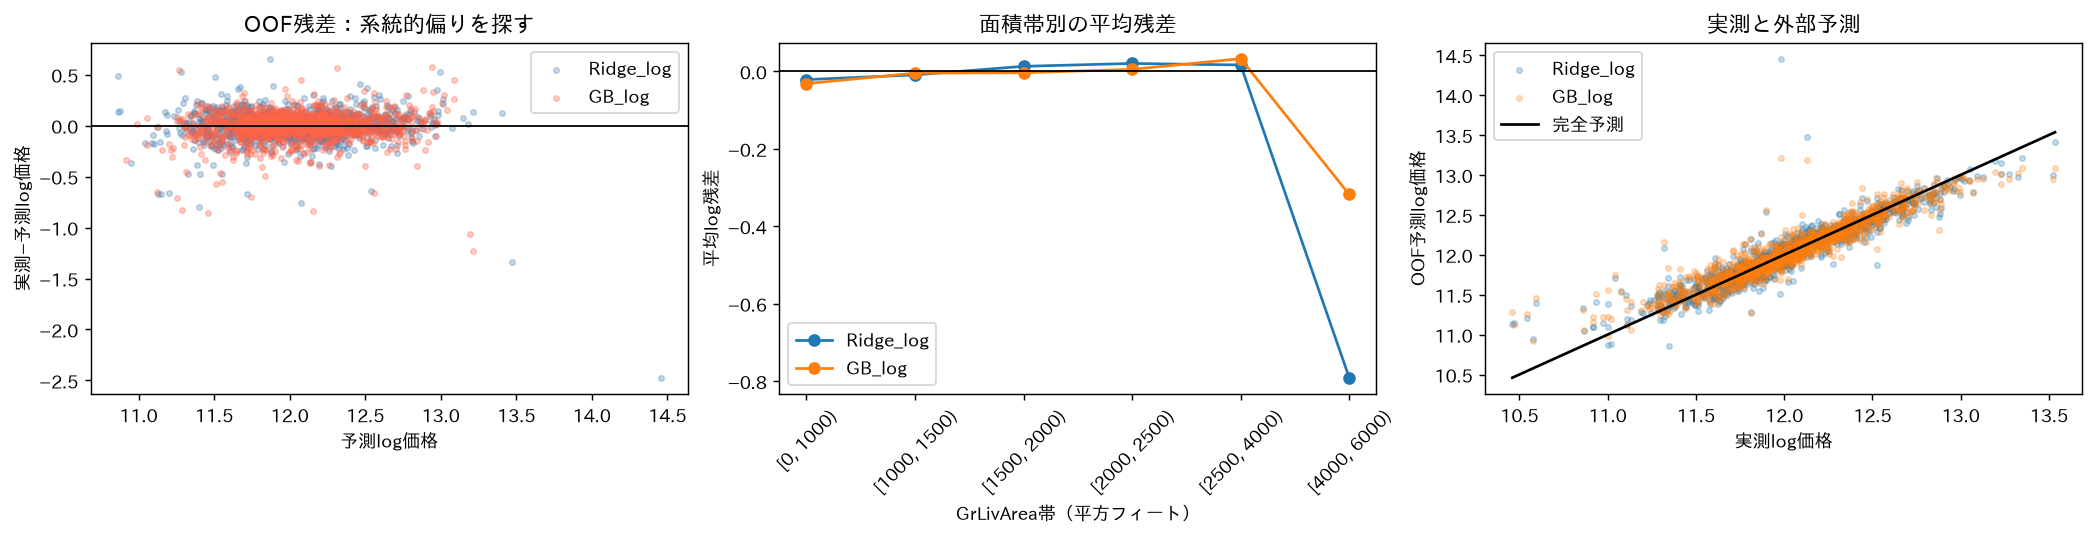

,count,mean,std
GrLivArea,,,
"[0, 1000)",231,-0.021290,0.140907
"[1000, 1500)",551,-0.009150,0.118009
"[1500, 2000)",463,0.013037,0.106366
"[2000, 2500)",145,0.020435,0.133754
"[2500, 4000)",66,0.016489,0.121204
"[4000, 6000)",4,-0.791273,1.378656


,count,mean,std
GrLivArea,,,
"[0, 1000)",231,-0.031570,0.140814
"[1000, 1500)",551,-0.004565,0.122504
"[1500, 2000)",463,-0.003497,0.107763
"[2000, 2500)",145,0.005134,0.144593
"[2500, 4000)",66,0.032738,0.130267
"[4000, 6000)",4,-0.317938,0.960407


'初回分析完了: 5-fold比較・Permutation importance・OOF残差を検証済み。'

In [10]:
from sklearn.inspection import permutation_importance
with tracked('外部予測残差と説明'), threadpool_limits(limits=2):
    importance_rows=[]
    for name in ['Ridge_log','GB_log']:
        fold_imp=[]
        for k,(train_idx,valid_idx) in enumerate(folds):
            model=make_model(name).fit(X.iloc[train_idx],log_y[train_idx])
            p=permutation_importance(model,X.iloc[valid_idx],log_y[valid_idx],scoring='neg_root_mean_squared_error',n_repeats=3,random_state=310+k,n_jobs=1)
            fold_imp.append(p.importances_mean)
        im=np.array(fold_imp)
        for j,c in enumerate(X.columns):
            importance_rows.append({'model':name,'feature':c,'increase_log_RMSE':im[:,j].mean(),'fold_SD':im[:,j].std(ddof=1)})
    importance_table=pd.DataFrame(importance_rows)
    for name in ['Ridge_log','GB_log']:
        print('未学習foldの元の列単位のPermutation importance:',name)
        display(importance_table.query('model==@name').sort_values('increase_log_RMSE',ascending=False).head(15))
    print('相関する特徴の重要度は分散する。独立な因果寄与や固有の説明割合ではない。')
    linear_model=fitted['Ridge_log']
    features=linear_model.named_steps['prep'].get_feature_names_out()
    coef=pd.DataFrame({'term':features,'coef_log_price':linear_model.named_steps['model'].coef_})
    coef['abs_coef']=coef.coef_log_price.abs()
    display(coef.sort_values('abs_coef',ascending=False).head(25))
    print('標準化数値の係数は1学習標準偏差あたり、カテゴリは対比基準のない全列OneHot+Ridge。単独のカテゴリ係数を因果プレミアムとしない。')
    residuals=pd.DataFrame({'Id':df.Id,'actual':y,'Ridge_log_error':log_y-np.log(oof['Ridge_log']),'GB_log_error':log_y-np.log(oof['GB_log']),'GrLivArea':df.GrLivArea,'OverallQual':df.OverallQual,'Neighborhood':df.Neighborhood})
    worst=residuals.assign(abs_error=lambda d:d.Ridge_log_error.abs()).sort_values('abs_error',ascending=False)
    display(worst.head(12))
    print('巨大面積候補（恣意的な価格基準で除外しない）:')
    display(df.loc[df.GrLivArea>4000,['Id','GrLivArea','OverallQual','SalePrice']])
    fig,axes=plt.subplots(1,3,figsize=(16,4),layout='constrained')
    for name,col,color in [('Ridge_log','Ridge_log_error','steelblue'),('GB_log','GB_log_error','tomato')]:
        axes[0].scatter(np.log(oof[name]),residuals[col],s=9,alpha=.3,color=color,label=name)
        binned=residuals.groupby(pd.cut(residuals.GrLivArea,[0,1000,1500,2000,2500,4000,6000],right=False),observed=True)[col].agg(['mean','count'])
        axes[1].plot(np.arange(len(binned)),binned['mean'],marker='o',label=name)
        axes[2].scatter(log_y,np.log(oof[name]),s=9,alpha=.25,label=name)
    axes[0].axhline(0,color='black',lw=1); axes[0].set(title='OOF残差：系統的偏りを探す',xlabel='予測log価格',ylabel='実測−予測log価格'); axes[0].legend()
    axes[1].axhline(0,color='black',lw=1); axes[1].set_xticks(np.arange(len(binned)),[str(v) for v in binned.index],rotation=45); axes[1].set(title='面積帯別の平均残差',xlabel='GrLivArea帯（平方フィート）',ylabel='平均log残差'); axes[1].legend()
    axes[2].plot([log_y.min(),log_y.max()],[log_y.min(),log_y.max()],color='black',label='完全予測'); axes[2].set(title='実測と外部予測',xlabel='実測log価格',ylabel='OOF予測log価格'); axes[2].legend()
    emit_figure(fig,'OOF残差診断')
    for name in ['Ridge_log','GB_log']:
        col=name+'_error'
        print('面積帯別誤差:',name)
        display(residuals.groupby(pd.cut(residuals.GrLivArea,[0,1000,1500,2000,2500,4000,6000],right=False),observed=True)[col].agg(['count','mean','std']))
    display('初回分析完了: 5-fold比較・Permutation importance・OOF残差を検証済み。')


## 反復依頼履歴

初回分析を読み直し、結論への影響が大きい未解決点から最大3回の追加分析を行う。依頼原文を下に変更せず記録する。

### 反復1：依頼原文

MasVnrTypeの欠損率が約60%になっています。元CSVの文字列NoneとNAを辞書に照らして区別し、設備なし・未観測の符号化を直してください。同じ5-foldで予測性能と主要特徴の結論が変わるかを確認し、Jupytermind側の取り込み仕様による情報損失とKaggle SDKの問題を切り分けて記録してください。

選定理由：欠損の意味とカテゴリ情報の保存が主要特徴の説明を変え得る。証拠：初回のMasVnrType欠損872件。

In [11]:
iteration_requests = []
iteration_requests.append({'iteration':1,'request':'MasVnrTypeの欠損率が約60%になっています。元CSVの文字列NoneとNAを辞書に照らして区別し、設備なし・未観測の符号化を直してください。同じ5-foldで予測性能と主要特徴の結論が変わるかを確認し、Jupytermind側の取り込み仕様による情報損失とKaggle SDKの問題を切り分けて記録してください。','reason':'高欠損率の解釈とカテゴリ情報の保存が結論に影響し得る','evidence':'初回のMasVnrType欠損872件/1460件'})
with tracked('反復1: 欠損の意味とカテゴリ保持'), threadpool_limits(limits=2):
    raw_strings=pd.read_csv(data_dir/FILES[0],keep_default_na=False,dtype=str)
    corrected_df=pd.read_csv(data_dir/FILES[0],keep_default_na=False,na_values=['NA',''])
    none_count=int((raw_strings.MasVnrType=='None').sum())
    raw_na_count=int((raw_strings.MasVnrType=='NA').sum())
    print('再現: literal None=',none_count,'literal NA=',raw_na_count,'ingestion欠損=',int(df.MasVnrType.isna().sum()),'保持後欠損=',int(corrected_df.MasVnrType.isna().sum()))
    print('MasVnrType辞書:',dictionary[dictionary.find('MasVnrType:'):dictionary.find('MasVnrType:')+400])
    print('その他Noneカテゴリ:',{c:int((raw_strings[c]=='None').sum()) for c in raw_strings if (raw_strings[c]=='None').any()})
    X_semantic=corrected_df.drop(columns=['Id','SalePrice']).copy()
    X_semantic['MSSubClass']=X_semantic.MSSubClass.astype(str)
    structural_rules={
        'PoolQC':('PoolArea','NoPool'), 'FireplaceQu':('Fireplaces','NoFireplace'),
        'GarageType':('GarageCars','NoGarage'),'GarageFinish':('GarageCars','NoGarage'),'GarageQual':('GarageCars','NoGarage'),'GarageCond':('GarageCars','NoGarage'),
        'BsmtQual':('TotalBsmtSF','NoBasement'),'BsmtCond':('TotalBsmtSF','NoBasement'),'BsmtExposure':('TotalBsmtSF','NoBasement'),
        'BsmtFinType1':('TotalBsmtSF','NoBasement'),'BsmtFinType2':('TotalBsmtSF','NoBasement')}
    encoding_log=[]
    for c,(quantity,none_label) in structural_rules.items():
        missing=X_semantic[c].isna(); absent=missing & X_semantic[quantity].eq(0)
        unknown=missing & ~absent
        X_semantic.loc[absent,c]=none_label
        X_semantic.loc[unknown,c]='UnknownRecordedMissing'
        encoding_log.append({'column':c,'structural_absence':int(absent.sum()),'unresolved_missing':int(unknown.sum())})
    for c,none_label in [('Alley','NoAlley'),('Fence','NoFence'),('MiscFeature','NoMiscFeature')]:
        n=int(X_semantic[c].isna().sum());X_semantic[c]=X_semantic[c].fillna(none_label)
        encoding_log.append({'column':c,'structural_absence':n,'unresolved_missing':0})
    X_semantic['MasVnrType']=X_semantic.MasVnrType.fillna('UnknownRecordedMissing')
    display(pd.DataFrame(encoding_log))
    display(corrected_df.loc[corrected_df.MasVnrType.isna(),['Id','MasVnrArea','SalePrice']])
    print('残る数値欠損:',X_semantic.isna().sum().loc[lambda s:s>0].to_dict())
    def evaluate_spec(matrix,kind,splits,train_selector=None):
        pred=np.zeros(len(matrix));rows=[]
        for k,(ti,vi) in enumerate(splits):
            if train_selector is not None:
                ti=ti[train_selector.iloc[ti].to_numpy()]
            model=make_model(kind).fit(matrix.iloc[ti],log_y[ti])
            pred[vi]=np.exp(model.predict(matrix.iloc[vi]))
            rows.append({'fold':k,'log_RMSE':float(np.sqrt(mean_squared_error(log_y[vi],np.log(pred[vi]))))})
        return {'log_RMSE':float(np.sqrt(mean_squared_error(log_y,np.log(pred)))),
            'MAE':float(mean_absolute_error(y,pred)),'RMSE':float(np.sqrt(mean_squared_error(y,pred))),'R2':float(r2_score(y,pred))},pred,rows
    corrected_oof={}; corrected_models={}; corrected_metrics=[]
    for name in ['Ridge_log','Spline_log','GB_log']:
        metrics,pred,rows=evaluate_spec(X_semantic,name,folds)
        corrected_oof[name]=pred
        corrected_models[name]=make_model(name).fit(X_semantic,log_y)
        corrected_metrics.append({'model':name,**metrics,'initial_log_RMSE':float(performance.loc[performance.model==name,'OOF_log_RMSE'].iloc[0])})
    corrected_performance=pd.DataFrame(corrected_metrics)
    corrected_performance['difference']=corrected_performance.log_RMSE-corrected_performance.initial_log_RMSE
    display(corrected_performance.round(6))
    iteration_requests[-1].update(result='NoneとNAの混同を再現。辞書と数量列から設備なしを分離し、同一foldで性能差を測定。',remaining_limit='MasVnrTypeのNA8件などは真の値を復元できない。設備なし符号化を独立データで検証していない。')
    print('反復1履歴:',json.dumps(iteration_requests[-1],ensure_ascii=False))
    display('反復1証拠: None=' +str(none_count)+', NA='+str(raw_na_count)+', unknown_missing='+str(int(corrected_df.MasVnrType.isna().sum())))


再現: literal None= 864 literal NA= 8 ingestion欠損= 872 保持後欠損= 8
MasVnrType辞書: MasVnrType: Masonry veneer type

       BrkCmn	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       None	None
       Stone	Stone
	
MasVnrArea: Masonry veneer area in square feet

ExterQual: Evaluates the quality of the material on the exterior 
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
ExterCond: Evaluates the present condi
その他Noneカテゴリ: {'MasVnrType': 864}
残る数値欠損: {'LotFrontage': 259, 'MasVnrArea': 8, 'Electrical': 1, 'GarageYrBlt': 81}
反復1履歴: {"iteration": 1, "request": "MasVnrTypeの欠損率が約60%になっています。元CSVの文字列NoneとNAを辞書に照らして区別し、設備なし・未観測の符号化を直してください。同じ5-foldで予測性能と主要特徴の結論が変わるかを確認し、Jupytermind側の取り込み仕様による情報損失とKaggle SDKの問題を切り分けて記録してください。", "reason": "高欠損率の解釈とカテゴリ情報の保存が結論に影響し得る", "evidence": "初回のMasVnrType欠損872件/1460件", "result": "NoneとNAの混同を再現。辞書と数量列から設備なしを分離し、同一foldで性能差を測定。", "remaining_limit": "MasVnrTypeのNA8件などは真の値を復元できない。設備なし符号化を独立データで検証してい

,column,structural_absence,unresolved_missing
0,PoolQC,1453,0
1,FireplaceQu,690,0
2,GarageType,81,0
3,GarageFinish,81,0
4,GarageQual,81,0
5,GarageCond,81,0
6,BsmtQual,37,0
7,BsmtCond,37,0
8,BsmtExposure,37,1
9,BsmtFinType1,37,0


,Id,MasVnrArea,SalePrice
234,235,NaN,216500
529,530,NaN,200624
650,651,NaN,205950
936,937,NaN,184900
973,974,NaN,182000
977,978,NaN,199900
1243,1244,NaN,465000
1278,1279,NaN,237000


,model,log_RMSE,MAE,RMSE,R2,initial_log_RMSE,difference
0,Ridge_log,0.142146,16542.053548,52980.954877,0.554927,0.142142,0.000004
1,Spline_log,0.128654,14713.503874,32996.102003,0.827370,0.128639,0.000015
2,GB_log,0.132846,16125.986594,29303.734820,0.863844,0.132899,-0.000053


'反復1証拠: None=864, NA=8, unknown_missing=8'

### 反復2：依頼原文

非線形モデルの改善は巨大な4住宅だけに依存していませんか。価格を使わないGrLivArea>4000という事前に読める基準で全標本と通常面積の標本を分け、分割seedとモデル選択の感度を検証してください。また面積・品質・築年・地下室・敷地面積を一つずつ曲線化して、どの非線形性が実際に外部予測を改善するかを調べ、交互作用が必須とは限らない点も説明してください。

選定理由：全体性能の改善を、少数の巨大住宅の影響と一般的な曲率の影響に切り分ける。証拠：OOF最大誤差のId1299・524はいずれも面積4000超。

sensitivity stable: False max_relative_deviation: 0.20841968706547662 tolerance: 0.15
対象集団が変わるためallと<=4000のスコア差を同じ母集団での改善とは呼ばない。元の全標本結果を主分析に残す。
単一曲線化は全標本で学習し通常面積のみの評価も併記。相互に相関する特徴なので独立な曲率寄与の分解ではない。
応答図は全標本fitの部分依存型診断。5–95%範囲だが相関した特徴を固定すると存在しない組合せも生む。品質の中間値は補間であり観測カテゴリではない。因果効果の推定ではない。
反復2履歴: {"iteration": 2, "request": "非線形モデルの改善は巨大な4住宅だけに依存していませんか。価格を使わないGrLivArea>4000という事前に読める基準で全標本と通常面積の標本を分け、分割seedとモデル選択の感度を検証してください。また面積・品質・築年・地下室・敷地面積を一つずつ曲線化して、どの非線形性が実際に外部予測を改善するかを調べ、交互作用が必須とは限らない点も説明してください。", "reason": "巨大住宅4件で価格尺度のRMSEが急増し、非線形の優位性が一部foldに集中", "evidence": "Ridge_log fold4 RMSE=104251、面積4000超4件", "result": "12仕様の外部予測感度、単一特徴曲線化、モデル応答を検証。非線形の優位性は仕様依存かを数値で報告。", "remaining_limit": "面積4000超は4件しかなく、極端な住宅の一般化を保証できない。部分依存は観測されない特徴の組合せを含み得る。"}


,model,area_limit,seed,n,log_RMSE,MAE,RMSE,R2
0,Ridge_log,all,31,1460,0.142146,16542.053548,52980.954877,0.554927
1,Ridge_log,all,131,1460,0.144729,16844.086747,57796.499048,0.470343
2,Ridge_log,4000,31,1456,0.113760,13517.979116,20122.479149,0.931117
3,Ridge_log,4000,131,1456,0.113375,13412.684877,20084.320911,0.931378
4,Spline_log,all,31,1460,0.128654,14713.503874,32996.102003,0.827370
5,Spline_log,all,131,1460,0.133298,15110.240719,36220.194268,0.791986
6,Spline_log,4000,31,1456,0.112520,13299.151532,20279.318525,0.930039
7,Spline_log,4000,131,1456,0.113043,13406.181313,20914.680907,0.925587
8,GB_log,all,31,1460,0.132846,16125.986594,29303.734820,0.863844
9,GB_log,all,131,1460,0.134071,16195.912734,30510.881634,0.852395


model              GB_log  Ridge_log  Spline_log  Ridge_minus_Spline  \
area_limit seed                                                        
4000       31    0.124558   0.113760    0.112520            0.001240   
           131   0.124083   0.113375    0.113043            0.000332   
all        31    0.132846   0.142146    0.128654            0.013492   
           131   0.134071   0.144729    0.133298            0.011431   

model            Ridge_minus_GB  
area_limit seed                  
4000       31         -0.010798  
           131        -0.010708  
all        31          0.009300  
           131         0.010657

,area_limit,n,quality_Spearman,area_Spearman
0,all,1460,0.809829,0.731310
1,4000,1456,0.810285,0.731238


,curved_feature,evaluation,log_RMSE,Ridge_minus_curve
0,GrLivArea,all,0.129352,0.012794
1,GrLivArea,typical_only_evaluation,0.114491,0.006439
2,OverallQual,all,0.142164,-0.000018
3,OverallQual,typical_only_evaluation,0.121526,-0.000596
4,YearBuilt,all,0.142507,-0.000361
5,YearBuilt,typical_only_evaluation,0.121169,-0.000239
6,TotalBsmtSF,all,0.132762,0.009384
7,TotalBsmtSF,typical_only_evaluation,0.115471,0.005459
8,LotArea,all,0.142451,-0.000304
9,LotArea,typical_only_evaluation,0.122727,-0.001797


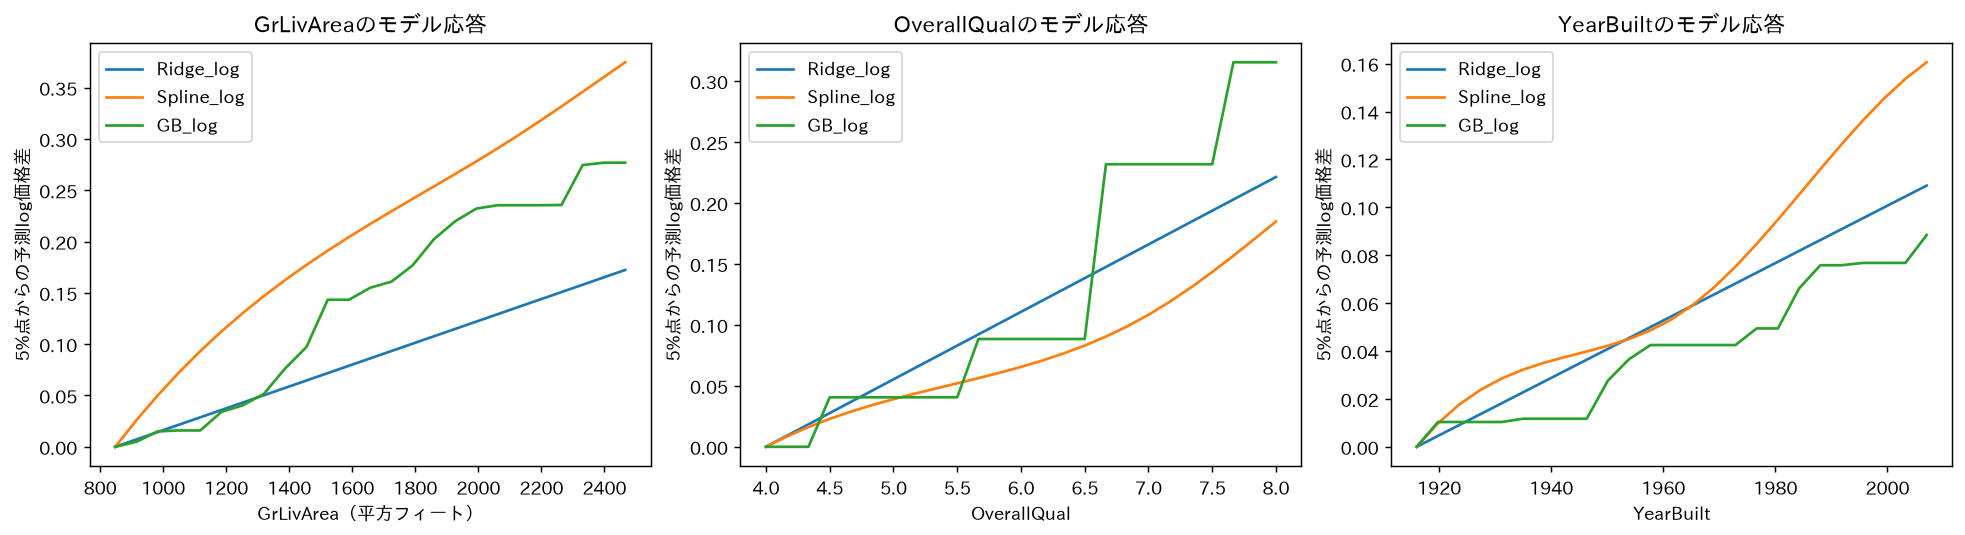

,feature,model,q05,q95,delta_log_price
0,GrLivArea,Ridge_log,848.0,2466.1,0.172352
1,GrLivArea,Spline_log,848.0,2466.1,0.374765
2,GrLivArea,GB_log,848.0,2466.1,0.276906
3,OverallQual,Ridge_log,4.0,8.0,0.221357
4,OverallQual,Spline_log,4.0,8.0,0.184848
5,OverallQual,GB_log,4.0,8.0,0.315481
6,YearBuilt,Ridge_log,1916.0,2007.0,0.109084
7,YearBuilt,Spline_log,1916.0,2007.0,0.160577
8,YearBuilt,GB_log,1916.0,2007.0,0.088457


'反復2証拠: sensitivity_stable=False, max_relative_deviation=0.20841968706547662'

In [12]:
from ai_data_scientist import sensitivity
iteration_requests.append({'iteration':2,'request':'非線形モデルの改善は巨大な4住宅だけに依存していませんか。価格を使わないGrLivArea>4000という事前に読める基準で全標本と通常面積の標本を分け、分割seedとモデル選択の感度を検証してください。また面積・品質・築年・地下室・敷地面積を一つずつ曲線化して、どの非線形性が実際に外部予測を改善するかを調べ、交互作用が必須とは限らない点も説明してください。','reason':'巨大住宅4件で価格尺度のRMSEが急増し、非線形の優位性が一部foldに集中','evidence':'Ridge_log fold4 RMSE=104251、面積4000超4件'})
sensitivity_rows=[]
def cv_sensitivity(model,area_limit,seed):
    pred=np.full(len(df),np.nan)
    splits=list(KFold(n_splits=5,shuffle=True,random_state=seed).split(X_semantic))
    accepted=np.ones(len(df),dtype=bool) if area_limit is None else df.GrLivArea.to_numpy()<=area_limit
    for ti,vi in splits:
        ti=ti[accepted[ti]];vi=vi[accepted[vi]]
        fitted_model=make_model(model).fit(X_semantic.iloc[ti],log_y[ti])
        pred[vi]=np.exp(fitted_model.predict(X_semantic.iloc[vi]))
    metrics={'log_RMSE':float(np.sqrt(mean_squared_error(log_y[accepted],np.log(pred[accepted])))),
        'MAE':float(mean_absolute_error(y[accepted],pred[accepted])),
        'RMSE':float(np.sqrt(mean_squared_error(y[accepted],pred[accepted]))),
        'R2':float(r2_score(y[accepted],pred[accepted]))}
    sensitivity_rows.append({'model':model,'area_limit':area_limit or 'all','seed':seed,'n':int(accepted.sum()),**metrics})
    return metrics['log_RMSE']
with tracked('反復2: 非線形・外れ値・分割感度'), threadpool_limits(limits=2):
    sensitivity_plan=sensitivity.SensitivityPlan(parameter_grid={'model':['Ridge_log','Spline_log','GB_log'],'area_limit':[None,4000],'seed':[31,131]},max_runs=12)
    sensitivity_report=sensitivity.run_sensitivity(sensitivity_plan,cv_sensitivity,stability_tolerance=.15)
    sensitivity_table=pd.DataFrame(sensitivity_rows)
    display(sensitivity_table.round(6))
    print('sensitivity stable:',sensitivity_report.stable,'max_relative_deviation:',sensitivity_report.max_relative_deviation,'tolerance:',.15)
    print('対象集団が変わるためallと<=4000のスコア差を同じ母集団での改善とは呼ばない。元の全標本結果を主分析に残す。')
    pivot=sensitivity_table.pivot(index=['area_limit','seed'],columns='model',values='log_RMSE')
    pivot['Ridge_minus_Spline']=pivot.Ridge_log-pivot.Spline_log
    pivot['Ridge_minus_GB']=pivot.Ridge_log-pivot.GB_log
    display(pivot.round(6))
    robust_correlations=[]
    for limit in [None,4000]:
        subset=df if limit is None else df.loc[df.GrLivArea<=limit]
        robust_correlations.append({'area_limit':limit or 'all','n':len(subset),'quality_Spearman':subset.OverallQual.corr(subset.SalePrice,method='spearman'),'area_Spearman':subset.GrLivArea.corr(subset.SalePrice,method='spearman')})
    display(pd.DataFrame(robust_correlations))
    ablation_rows=[]; ablation_predictions={}
    for curve in ['GrLivArea','OverallQual','YearBuilt','TotalBsmtSF','LotArea']:
        pred=np.zeros(len(df))
        for ti,vi in folds:
            linear=[c for c in num_cols if c!=curve]
            prep=ColumnTransformer([
                ('numeric',Pipeline([('fill',SimpleImputer(strategy='median',add_indicator=True)),('scale',StandardScaler())]),linear),
                ('spline',Pipeline([('fill',SimpleImputer(strategy='median')),('basis',SplineTransformer(n_knots=4,degree=3,include_bias=False)),('scale',StandardScaler())]),[curve]),
                ('category',Pipeline([('fill',SimpleImputer(strategy='constant',fill_value='Missing_or_None')),('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False))]),cat_cols)],sparse_threshold=0)
            model=Pipeline([('prep',prep),('model',Ridge(alpha=20))]).fit(X_semantic.iloc[ti],log_y[ti])
            pred[vi]=np.exp(model.predict(X_semantic.iloc[vi]))
        ablation_predictions[curve]=pred
        for scope,mask in [('all',np.ones(len(df),dtype=bool)),('typical_only_evaluation',df.GrLivArea.to_numpy()<=4000)]:
            base=float(np.sqrt(mean_squared_error(log_y[mask],np.log(corrected_oof['Ridge_log'][mask]))))
            rmse=float(np.sqrt(mean_squared_error(log_y[mask],np.log(pred[mask]))))
            ablation_rows.append({'curved_feature':curve,'evaluation':scope,'log_RMSE':rmse,'Ridge_minus_curve':base-rmse})
    ablation_table=pd.DataFrame(ablation_rows)
    display(ablation_table.round(6))
    print('単一曲線化は全標本で学習し通常面積のみの評価も併記。相互に相関する特徴なので独立な曲率寄与の分解ではない。')
    anchors=X_semantic.sample(n=180,random_state=31)
    fig,axes=plt.subplots(1,3,figsize=(15,4),layout='constrained')
    response_rows=[]
    for ax,feature in zip(axes,['GrLivArea','OverallQual','YearBuilt']):
        grid=np.linspace(float(X_semantic[feature].quantile(.05)),float(X_semantic[feature].quantile(.95)),25)
        for name in ['Ridge_log','Spline_log','GB_log']:
            averaged=[]
            for value in grid:
                changed=anchors.copy();changed[feature]=value
                averaged.append(float(corrected_models[name].predict(changed).mean()))
            centered=np.array(averaged)-averaged[0]
            ax.plot(grid,centered,label=name)
            response_rows.append({'feature':feature,'model':name,'q05':float(grid[0]),'q95':float(grid[-1]),'delta_log_price':float(centered[-1])})
        ax.set(title=feature+'のモデル応答',xlabel=feature+('（平方フィート）' if feature=='GrLivArea' else ''),ylabel='5%点からの予測log価格差');ax.legend()
    emit_figure(fig,'非線形モデル応答（非因果）')
    display(pd.DataFrame(response_rows))
    print('応答図は全標本fitの部分依存型診断。5–95%範囲だが相関した特徴を固定すると存在しない組合せも生む。品質の中間値は補間であり観測カテゴリではない。因果効果の推定ではない。')
    iteration_requests[-1].update(result='12仕様の外部予測感度、単一特徴曲線化、モデル応答を検証。非線形の優位性は仕様依存かを数値で報告。',remaining_limit='面積4000超は4件しかなく、極端な住宅の一般化を保証できない。部分依存は観測されない特徴の組合せを含み得る。')
    print('反復2履歴:',json.dumps(iteration_requests[-1],ensure_ascii=False))
    display('反復2証拠: sensitivity_stable='+str(sensitivity_report.stable)+', max_relative_deviation='+str(sensitivity_report.max_relative_deviation))


### 反復3：依頼原文

無作為分割の性能を将来や未学習地区へそのまま外挿してよいか確認してください。2006–2008年で学習して2009–2010年を評価し、NeighborhoodごとのGroupKFoldも使ってください。カテゴリ変数全体・地区・取引条件を除く比較と、補正済みスプラインモデルの外部fold重要度を追加し、予測精度の高さと説明の妥当性を分けた最終結論をまとめてください。

選定理由：予測を適用する時期と地域に応じて必要な検証が異なり、無作為分割だけでは外挿を保証しない。反復2で特徴の関連は安定しても性能の安定判定はFalseだった。

In [13]:
from sklearn.model_selection import GroupKFold
iteration_requests.append({'iteration':3,'request':'無作為分割の性能を将来や未学習地区へそのまま外挿してよいか確認してください。2006–2008年で学習して2009–2010年を評価し、NeighborhoodごとのGroupKFoldも使ってください。カテゴリ変数全体・地区・取引条件を除く比較と、補正済みスプラインモデルの外部fold重要度を追加し、予測精度の高さと説明の妥当性を分けた最終結論をまとめてください。','reason':'無作為foldの同分布前提は未検証であり、地区差の説明と新地区への予測は異なる','evidence':'前提manifest A2はassumed、地区別中央値に大きな差'})
with tracked('反復3: 時間・地区・説明の適用範囲'), threadpool_limits(limits=2):
    transfer_rows=[]
    time_train=np.flatnonzero(df.YrSold.to_numpy()<=2008)
    time_valid=np.flatnonzero(df.YrSold.to_numpy()>=2009)
    group_splits=list(GroupKFold(n_splits=5).split(X_semantic,log_y,groups=df.Neighborhood))
    for name in ['Ridge_log','Spline_log','GB_log']:
        temporal_model=make_model(name).fit(X_semantic.iloc[time_train],log_y[time_train])
        pred=np.exp(temporal_model.predict(X_semantic.iloc[time_valid]))
        transfer_rows.append({'validation':'train2006-08/test2009-10','model':name,'train_n':len(time_train),'test_n':len(time_valid),'log_RMSE':float(np.sqrt(mean_squared_error(log_y[time_valid],np.log(pred)))),'MAE':float(mean_absolute_error(y[time_valid],pred)),'R2':float(r2_score(y[time_valid],pred))})
        gm,gpred,grows=evaluate_spec(X_semantic,name,group_splits)
        transfer_rows.append({'validation':'Neighborhood GroupKFold','model':name,'train_n':'foldごと','test_n':len(df),'log_RMSE':gm['log_RMSE'],'MAE':gm['MAE'],'R2':gm['R2']})
    transfer_table=pd.DataFrame(transfer_rows)
    display(transfer_table.round(6))
    print('時間分割は単一の歴史的検証で、2026年への検証ではない。地区GroupKFoldはAmes内の未学習地区であって他都市の独立データではない。')
    category_rows=[]
    subsets={'full':list(X_semantic.columns),
        'without_Neighborhood':[c for c in X_semantic if c!='Neighborhood'],
        'numeric_only':num_cols,
        'without_sale_information':[c for c in X_semantic if c not in ['SaleType','SaleCondition']]}
    for subset,columns in subsets.items():
        for name in ['Ridge_log','Spline_log']:
            pred=np.zeros(len(df))
            for ti,vi in folds:
                model=make_model(name,columns=columns).fit(X_semantic.iloc[ti],log_y[ti])
                pred[vi]=np.exp(model.predict(X_semantic.iloc[vi]))
            category_rows.append({'subset':subset,'model':name,'log_RMSE':float(np.sqrt(mean_squared_error(log_y,np.log(pred)))),'MAE':float(mean_absolute_error(y,pred))})
    category_ablation=pd.DataFrame(category_rows)
    display(category_ablation.round(6))
    print('地区除去の差は他の特徴が持つ地区情報と冗長。地域の因果効果の推定ではない。取引情報は予測時点で未知なら使用禁止。')
    corrected_importance=[]
    for k,(ti,vi) in enumerate(folds):
        model=make_model('Spline_log').fit(X_semantic.iloc[ti],log_y[ti])
        pi=permutation_importance(model,X_semantic.iloc[vi],log_y[vi],n_repeats=3,random_state=310+k,scoring='neg_root_mean_squared_error',n_jobs=1)
        corrected_importance.append(pi.importances_mean)
    imp=np.array(corrected_importance)
    spline_importance=pd.DataFrame({'feature':X_semantic.columns,'increase_log_RMSE':imp.mean(axis=0),'fold_SD':imp.std(axis=0,ddof=1)}).sort_values('increase_log_RMSE',ascending=False)
    display(spline_importance.head(15))
    semantic_missing=corrected_df.isna().sum().sort_values(ascending=False)
    print('補正後の欠損（構造的NAを含む）:');display(semantic_missing[semantic_missing>0].to_frame('count'))
    assumptions_final=analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'population':'Ames 2006–2010年の取引','prediction':'固定仕様のOOF・時期分割・地区分割比較','causal_effects':'非対象'},
        assumptions=(analysis_assumptions.Assumption('A1','観察上の関連であり因果効果にしない','verified',conclusion_critical=True),
            analysis_assumptions.Assumption('A2','同分布・時間・地区別の検証範囲を区別する','tested',conclusion_critical=True),
            analysis_assumptions.Assumption('A3','前処理fitは学習foldだけで行う','verified',conclusion_critical=True),
            analysis_assumptions.Assumption('A4','NoneとNAおよび設備なしを辞書・数量と照合する','tested',conclusion_critical=True),
            analysis_assumptions.Assumption('A5','評価標本は重複物件を含まない取引単位とみなす','assumed',impact_if_false='同一物件の別取引が分割をまたぎ過大評価し得る。住所キーなし',conclusion_critical=True),
            analysis_assumptions.Assumption('A6','取引条件などが予測時に利用可能な場面を想定する','assumed',impact_if_false='販売前予測では利用できず性能が下がり得る',conclusion_critical=True)),
        causal_scope='associational',sampling={'n':len(df),'seed':31})
    print('最終前提manifest:',json.dumps(asdict(assumptions_final),ensure_ascii=False,indent=2))
    print('最終前提findings:',[asdict(f) for f in analysis_assumptions.check_manifest(assumptions_final)])
    iteration_requests[-1].update(result='時期・地区分割、カテゴリ除去比較、補正済み最良logモデルの外部重要度で説明と適用範囲を再確認。',remaining_limit='同一物件の再取引を検出する住所キーなし。現代・他都市のラベル付き独立標本はなく、因果識別もない。')
    print('反復3履歴:',json.dumps(iteration_requests[-1],ensure_ascii=False))
    print('停止理由: 3回の上限に到達。残る独立データ・因果識別・物件キー不足は同じデータの追加計算では解消できず、一般化を限定して報告する。')
    display('反復3証拠: historical_train_n='+str(len(time_train))+', historical_test_n='+str(len(time_valid))+', validation=Neighborhood GroupKFold')


時間分割は単一の歴史的検証で、2026年への検証ではない。地区GroupKFoldはAmes内の未学習地区であって他都市の独立データではない。
地区除去の差は他の特徴が持つ地区情報と冗長。地域の因果効果の推定ではない。取引情報は予測時点で未知なら使用禁止。
補正後の欠損（構造的NAを含む）:
最終前提manifest: {
  "analysis_scope": {
    "population": "Ames 2006–2010年の取引",
    "prediction": "固定仕様のOOF・時期分割・地区分割比較",
    "causal_effects": "非対象"
  },
  "assumptions": [
    {
      "id": "A1",
      "statement": "観察上の関連であり因果効果にしない",
      "status": "verified",
      "evidence_cell": null,
      "impact_if_false": null,
      "conclusion_critical": true
    },
    {
      "id": "A2",
      "statement": "同分布・時間・地区別の検証範囲を区別する",
      "status": "tested",
      "evidence_cell": null,
      "impact_if_false": null,
      "conclusion_critical": true
    },
    {
      "id": "A3",
      "statement": "前処理fitは学習foldだけで行う",
      "status": "verified",
      "evidence_cell": null,
      "impact_if_false": null,
      "conclusion_critical": true
    },
    {
      "id": "A4",
      "statement": "NoneとNAおよび設備なしを辞書・数量と照合する",
      "status": "tested",
  

,validation,model,train_n,test_n,log_RMSE,MAE,R2
0,train2006-08/test2009-10,Ridge_log,947,513,0.134494,16814.517581,0.897895
1,Neighborhood GroupKFold,Ridge_log,foldごと,1460,0.159214,19516.439965,0.204906
2,train2006-08/test2009-10,Spline_log,947,513,0.128695,14822.947317,0.922443
3,Neighborhood GroupKFold,Spline_log,foldごと,1460,0.149884,17320.547473,0.636984
4,train2006-08/test2009-10,GB_log,947,513,0.141478,16482.073438,0.892350
5,Neighborhood GroupKFold,GB_log,foldごと,1460,0.151077,18472.022299,0.820201


,subset,model,log_RMSE,MAE
0,full,Ridge_log,0.142146,16542.053548
1,full,Spline_log,0.128654,14713.503874
2,without_Neighborhood,Ridge_log,0.146964,17508.620414
3,without_Neighborhood,Spline_log,0.132693,15385.917734
4,numeric_only,Ridge_log,0.159925,19518.024896
5,numeric_only,Spline_log,0.138309,16558.215695
6,without_sale_information,Ridge_log,0.142868,16701.453140
7,without_sale_information,Spline_log,0.129550,14911.118700


,feature,increase_log_RMSE,fold_SD
45,GrLivArea,0.074418,0.007390
16,OverallQual,0.033086,0.003948
18,YearBuilt,0.022586,0.008412
37,TotalBsmtSF,0.020310,0.002522
17,OverallCond,0.018969,0.003548
11,Neighborhood,0.006963,0.001475
3,LotArea,0.003987,0.002736
43,2ndFlrSF,0.003774,0.001996
1,MSZoning,0.003468,0.002087
60,GarageCars,0.003032,0.003098


,count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
FireplaceQu,690
LotFrontage,259
GarageFinish,81
GarageQual,81
GarageYrBlt,81
GarageType,81


'反復3証拠: historical_train_n=947, historical_test_n=513, validation=Neighborhood GroupKFold'

## 日本語の結論：予測性能と説明は同じではない

品質（OverallQual）と地上居住面積（GrLivArea）は、単変量の関連でも外部foldの予測重要度でも主要特徴である。築年・地下室面積・現況・地区がそれを補う。ただし地上面積と階別面積、地下室と1階面積などは相関するため、各重要度を足して独立の説明割合にはできない。Ridge係数とPermutation importanceの順位が違うこと自体は矛盾ではなく、モデルの表現と冗長な情報配分の違いである。

生価格は右に歪む。対数化は分布を対称に近づけるが、価格の正規性や残差の正規性を保証しない。対数線形モデルでも地上面積・地下室面積の曲線化がOOF誤差を減らす。一方、品質・築年・敷地を単独で曲線化する改善はこの固定仕様では確認できず、形状図だけで非線形が必要とは主張しない。加法スプラインがlog RMSEとMAEで最良でも、交互作用を許すGBの価格尺度RMSEは小さい。したがって「複雑な交互作用モデルなら常に優れる」とは言えない。

全標本でのスプライン改善は少数の巨大住宅に強く影響される。4000平方フィート以下ではRidgeとスプラインの差が小さく、GBはRidgeより悪化する。この除外は価格を見ずに定義した感度分析であり、原データを削除して主結果を良く見せる操作ではない。性能の感度判定はFalse（許容15%）で、モデルの優位性を普遍的に「頑健」とは呼ばない。対照的に品質・面積の順位相関はこの除外でも安定している。

PoolQC等の高欠損率の多くは「設備なし」。MasVnrTypeはNone864件と本当のNA8件を区別すべきで、既定読込みの872件欠損は解釈を誤らせる。意味的検査では改築年が売却年の後のId524を1件検出した。修正方法が確定していないため主分析では保持し、売却年への制限・未知値化の感度を併記する。未知欠損を実在するカテゴリに憶測で割り当てない。

無作為foldは同時期・同地域に近い未知取引向けの検証。未学習地区では性能が低下し、歴史的な時間分割は現在や他都市を保証しない。地区差は住宅構成・品質・立地が混ざった観察的関連であり、地区への移動や改修による値上がりの因果効果ではない。モデル選択後のスコアには選択バイアスがあり、独立した最終holdout・住所キー・独立データ・因果識別がない。取引条件を販売前の予測に使えるかも未確定であり、除去した比較を判断材料とする。単位・利用許諾・全国代表性・辞書名と一致しないBedroomAbvGr/KitchenAbvGrの定義は未確認として残す。

以下の実行出力とevidence付き結論を、数値根拠として参照する。


改築年の扱いの追加感度：Id524を売却年に制限したスプラインlog RMSEは0.128648、未知値化すると0.132692（原記録0.128654）。未知値化では価格RMSEも42,772へ増加した。1件の記録と補完・欠損指標の変更でも極端値への応答が変わるため、原記録の処理を変えても常に同じランキングになるとは保証しない。主分析と感度分析は区別する。

In [14]:
from ai_data_scientist import notebook_audit
import nbformat
import sklearn
with tracked('最終要約・改善候補の再現検証'), threadpool_limits(limits=2):
    print('実行環境:',{'python':sys.version.split()[0],'pandas':pd.__version__,'numpy':np.__version__,'sklearn':sklearn.__version__})
    future_date_sensitivity=[]
    for treatment in ['cap_to_sale_year','unknown']:
        matrix=X_semantic.copy()
        mask=df.YearRemodAdd>df.YrSold
        matrix.loc[mask,'YearRemodAdd']=df.loc[mask,'YrSold'] if treatment=='cap_to_sale_year' else np.nan
        metrics,pred,rows=evaluate_spec(matrix,'Spline_log',folds)
        future_date_sensitivity.append({'treatment':treatment,**metrics})
    print('Id524（売却2007、改築記録2008）の扱いの感度:');display(pd.DataFrame(future_date_sensitivity).round(6))
    print('断定的な修正や削除はせず、主分析では原記録を保持。販売時点で不可能な値である可能性を限定として残す。')
    correlation_sensitivity=[]
    for feature in ['OverallQual','GrLivArea']:
        plan=sensitivity.SensitivityPlan(parameter_grid={'area_limit':[None,4000]},max_runs=2)
        def calc_correlation(area_limit, feature=feature):
            rows=df if area_limit is None else df.loc[df.GrLivArea<=area_limit]
            return rows[feature].corr(rows.SalePrice,method='spearman')
        report=sensitivity.run_sensitivity(plan,calc_correlation,stability_tolerance=.05)
        correlation_sensitivity.append({'feature':feature,'stable':report.stable,'max_relative_deviation':report.max_relative_deviation})
    display(pd.DataFrame(correlation_sensitivity))
    probe=nbformat.v4.new_notebook(cells=[nbformat.v4.new_code_cell('display(chart)',execution_count=1,outputs=[visualization.build_image_output(visualization.render_chart(df,kind='hist',x='SalePrice',title='metadata probe',xlabel='price',ylabel='count'))])])
    probe_findings=notebook_audit.audit_visual_outputs(probe,(0,))
    print('改善候補2再現: chart metadata absent ->', [asdict(f) for f in probe_findings])
    improvement_candidates=[
        {'classification':'機能不足（CSVカテゴリの意味保存）','module':'ai_data_scientist.ingestion.ingest / SourceSpec',
            'reproduction':'元CSVのMasVnrTypeにNone864件とNA8件がある状態でingest(SourceSpec(csv,...))',
            'expected':'Noneカテゴリを保持し、NAだけを欠損として明示設定できる',
            'actual':'pd.read_csv既定値で両者をNaNに変換し872件欠損。SourceSpecにna_values/keep_default_naを指定する手段がない',
            'impact':'欠損率を59.7%と誤読。補正後0.55%。このデータの予測差は小さくても設備なしと未観測の説明が混ざる',
            'workaround':'pd.read_csv(keep_default_na=False,na_values=[NA,空文字])をNotebook内で直接使用し辞書で設備なしを区別',
            'cells':'取得5・定義7・反復1の15（0-based）','logs':'反復1: None=864, NA=8, ingestion欠損=872, 保持後欠損=8'},
        {'classification':'監査機能不足（メタデータ欠落の未検出）','module':'ai_data_scientist.notebook_audit.audit_visual_outputs',
            'reproduction':'有効PNGを持つcode cellでmetadata.chartを空にしaudit_visual_outputsを呼ぶ。本セルのprobeで再現',
            'expected':'glyph・title・軸ラベル・legendの監査情報がないことを警告する',
            'actual':'空のfindingsを返す（監査情報がない場合にラベル検査をスキップ）',
            'impact':'メタデータを付けない通常の図がvisual_auditで未検査のまま合格し得る。初回図にはIPAexGothicで>=記号のUnicode版が欠けた',
            'workaround':'描画時のGlyph警告を捕捉、ASCII >=に置換、目視確認し、全画像セルにchartメタデータをenqueue_writeで付与',
            'cells':'探索9・反復2の17・本セル','logs':'初回探索9: Glyph 8805 missing（修正済み）。本セル: chart metadata absent -> []'}]
    print('Jupytermind改善候補:',json.dumps(improvement_candidates,ensure_ascii=False,indent=2))
    print('切り分け: SDK未対応page_size引数とURLエンコード保存名はKaggle SDK/分析呼出側。初期tracked戻り値の欠落は分析コード。Copilot CLIとベンチマークランナーの障害は確認していない。')
    quality_r=float(df.OverallQual.corr(df.SalePrice));area_r=float(df.GrLivArea.corr(df.SalePrice))
    display(f'根拠|主要特徴|品質Pearson={quality_r:.6f}; 地上面積Pearson={area_r:.6f}; 補正スプライン重要度上位='+','.join(spline_importance.head(6).feature))
    display(f'根拠|分布欠損|価格歪度={df.SalePrice.skew():.6f}; log歪度={np.log(df.SalePrice).skew():.6f}; MasVnrType:None={none_count},NA={raw_na_count}')
    for _,row in corrected_performance.iterrows():
        display(f'根拠|性能|{row.model}:log_RMSE={row.log_RMSE:.6f},MAE={row.MAE:.2f},RMSE={row.RMSE:.2f},R2={row.R2:.6f}')
    improvement=(float(corrected_performance.loc[corrected_performance.model=='Ridge_log','log_RMSE'].iloc[0])-float(corrected_performance.loc[corrected_performance.model=='Spline_log','log_RMSE'].iloc[0]))/float(corrected_performance.loc[corrected_performance.model=='Ridge_log','log_RMSE'].iloc[0])
    display(f'根拠|非線形|対数RMSEのスプライン改善率={improvement:.6f}; 性能感度stable={sensitivity_report.stable},最大相対偏差={sensitivity_report.max_relative_deviation:.6f}')
    group_rmse=float(transfer_table.loc[(transfer_table.model=='Spline_log')&(transfer_table.validation=='Neighborhood GroupKFold'),'log_RMSE'].iloc[0])
    display(f'根拠|適用範囲|未学習地区スプラインlog_RMSE={group_rmse:.6f}; 歴史時間分割n={len(time_train)}/{len(time_valid)}')
    print('反復履歴（依頼原文・選定理由・結果・証拠・限界）:',json.dumps(iteration_requests,ensure_ascii=False,indent=2))
    print('図表検査ログ:',json.dumps(chart_checks,ensure_ascii=False))


実行環境: {'python': '3.12.3', 'pandas': '3.0.6', 'numpy': '2.5.3', 'sklearn': '1.9.1'}
Id524（売却2007、改築記録2008）の扱いの感度:
断定的な修正や削除はせず、主分析では原記録を保持。販売時点で不可能な値である可能性を限定として残す。
改善候補2再現: chart metadata absent -> []
Jupytermind改善候補: [
  {
    "classification": "機能不足（CSVカテゴリの意味保存）",
    "module": "ai_data_scientist.ingestion.ingest / SourceSpec",
    "reproduction": "元CSVのMasVnrTypeにNone864件とNA8件がある状態でingest(SourceSpec(csv,...))",
    "expected": "Noneカテゴリを保持し、NAだけを欠損として明示設定できる",
    "actual": "pd.read_csv既定値で両者をNaNに変換し872件欠損。SourceSpecにna_values/keep_default_naを指定する手段がない",
    "impact": "欠損率を59.7%と誤読。補正後0.55%。このデータの予測差は小さくても設備なしと未観測の説明が混ざる",
    "workaround": "pd.read_csv(keep_default_na=False,na_values=[NA,空文字])をNotebook内で直接使用し辞書で設備なしを区別",
    "cells": "取得5・定義7・反復1の15（0-based）",
    "logs": "反復1: None=864, NA=8, ingestion欠損=872, 保持後欠損=8"
  },
  {
    "classification": "監査機能不足（メタデータ欠落の未検出）",
    "module": "ai_data_scientist.notebook_audit.audit_visual_outputs",
    "reproduction": "有効PNGを持つcode cell

,treatment,log_RMSE,MAE,RMSE,R2
0,cap_to_sale_year,0.128648,14712.907058,32987.238152,0.827462
1,unknown,0.132692,14651.853727,42772.282602,0.709921


,feature,stable,max_relative_deviation
0,OverallQual,True,0.000564
1,GrLivArea,True,0.000098


'根拠|主要特徴|品質Pearson=0.790982; 地上面積Pearson=0.708624; 補正スプライン重要度上位=GrLivArea,OverallQual,YearBuilt,TotalBsmtSF,OverallCond,Neighborhood'

'根拠|分布欠損|価格歪度=1.882876; log歪度=0.121335; MasVnrType:None=864,NA=8'

'根拠|性能|Ridge_log:log_RMSE=0.142146,MAE=16542.05,RMSE=52980.95,R2=0.554927'

'根拠|性能|Spline_log:log_RMSE=0.128654,MAE=14713.50,RMSE=32996.10,R2=0.827370'

'根拠|性能|GB_log:log_RMSE=0.132846,MAE=16125.99,RMSE=29303.73,R2=0.863844'

'根拠|非線形|対数RMSEのスプライン改善率=0.094919; 性能感度stable=False,最大相対偏差=0.208420'

'根拠|適用範囲|未学習地区スプラインlog_RMSE=0.149884; 歴史時間分割n=947/513'

**根拠付き結論：品質・面積の粗い関連と調整後の予測情報**

根拠|主要特徴|品質Pearson=0.790982; 地上面積Pearson=0.708624; 補正スプライン重要度上位=GrLivArea,OverallQual,YearBuilt,TotalBsmtSF,OverallCond,Neighborhood

```evidence
{"execution_count":14,"cited_value":"\u6839\u62e0|\u4e3b\u8981\u7279\u5fb4|\u54c1\u8ceaPearson=0.790982; \u5730\u4e0a\u9762\u7a4dPearson=0.708624; \u88dc\u6b63\u30b9\u30d7\u30e9\u30a4\u30f3\u91cd\u8981\u5ea6\u4e0a\u4f4d=GrLivArea,OverallQual,YearBuilt,TotalBsmtSF,OverallCond,Neighborhood","claim_type":"associational"}
```

**根拠付き結論：価格の歪みとNone/NAの意味の違い**

根拠|分布欠損|価格歪度=1.882876; log歪度=0.121335; MasVnrType:None=864,NA=8

```evidence
{"execution_count":14,"cited_value":"\u6839\u62e0|\u5206\u5e03\u6b20\u640d|\u4fa1\u683c\u6b6a\u5ea6=1.882876; log\u6b6a\u5ea6=0.121335; MasVnrType:None=864,NA=8","claim_type":"associational"}
```

**根拠付き結論：対数線形Ridgeの同分布OOF性能**

根拠|性能|Ridge_log:log_RMSE=0.142146,MAE=16542.05,RMSE=52980.95,R2=0.554927

```evidence
{"execution_count":14,"cited_value":"\u6839\u62e0|\u6027\u80fd|Ridge_log:log_RMSE=0.142146,MAE=16542.05,RMSE=52980.95,R2=0.554927","claim_type":"associational"}
```

**根拠付き結論：加法スプラインの同分布OOF性能**

根拠|性能|Spline_log:log_RMSE=0.128654,MAE=14713.50,RMSE=32996.10,R2=0.827370

```evidence
{"execution_count":14,"cited_value":"\u6839\u62e0|\u6027\u80fd|Spline_log:log_RMSE=0.128654,MAE=14713.50,RMSE=32996.10,R2=0.827370","claim_type":"associational"}
```

**根拠付き結論：交互作用を許すGBの同分布OOF性能**

根拠|性能|GB_log:log_RMSE=0.132846,MAE=16125.99,RMSE=29303.73,R2=0.863844

```evidence
{"execution_count":14,"cited_value":"\u6839\u62e0|\u6027\u80fd|GB_log:log_RMSE=0.132846,MAE=16125.99,RMSE=29303.73,R2=0.863844","claim_type":"associational"}
```

**根拠付き結論：曲線化の改善と性能の仕様依存性**

根拠|非線形|対数RMSEのスプライン改善率=0.094919; 性能感度stable=False,最大相対偏差=0.208420

```evidence
{"execution_count":14,"cited_value":"\u6839\u62e0|\u975e\u7dda\u5f62|\u5bfe\u6570RMSE\u306e\u30b9\u30d7\u30e9\u30a4\u30f3\u6539\u5584\u7387=0.094919; \u6027\u80fd\u611f\u5ea6stable=False,\u6700\u5927\u76f8\u5bfe\u504f\u5dee=0.208420","claim_type":"associational"}
```

**根拠付き結論：未学習地区と歴史的時間分割の適用範囲**

根拠|適用範囲|未学習地区スプラインlog_RMSE=0.149884; 歴史時間分割n=947/513

```evidence
{"execution_count":14,"cited_value":"\u6839\u62e0|\u9069\u7528\u7bc4\u56f2|\u672a\u5b66\u7fd2\u5730\u533a\u30b9\u30d7\u30e9\u30a4\u30f3log_RMSE=0.149884; \u6b74\u53f2\u6642\u9593\u5206\u5272n=947/513","claim_type":"associational"}
```

## Jupytermind改善候補

分類・再現条件・期待する挙動・実際の挙動・影響・回避策・関係セル・ログは直前セルのimprovement_candidatesに記録した。CSVのNA設定不足と、図表監査のメタデータ欠落未検出の2候補。SDK引数・SDKのURLエンコード保存名・分析コードの初期ミスと区別し、ソフトウェアの修正やIssue作成は今回行わない。

## 使用したJupytermindモジュール

この節は直接import・呼び出したものだけを列挙する。間接利用は数えない。分析・取得・制御コードはいずれもJupyter MCP実行セル内で実行した。

| 直接利用モジュール（ai_data_scientist.*） | 直接呼び出した関数・型 | 目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 指定slugの解決・安定した保存先・データ保存・書込み直列化。enqueue_writeはJupyter MCP制御Notebookで直接使用 |
| language_router | detect_language | 日本語の分析・記録 |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_failed, mark_completed, get_run_status | 長時間実行・書込み・失敗・完了状態の記録 |
| ingestion | SourceSpec, ingest | 初回CSV読込み。反復1で既定NA変換の限界を確認 |
| cleaning | clean_dataset | 完全一致重複の検査。削除0行、1460行を保持 |
| eda | explore | 型・要約・全列欠損・カテゴリ上位値と比率 |
| stats_analysis | correlation | 価格と主要数値変数のPearson相関・日本語解釈 |
| data_definition | FieldValue, build_manifest; manifest.unresolved_fields | 出所・SHA・列定義・単位の確認状態を明示 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 観察的範囲・分割・NA・可用性・再取引仮定と警告 |
| data_quality | detect_anomalies | 範囲・一意性・必須値・カテゴリ許容値の意味的検査 |
| visualization | render_chart, build_image_output | 日本語図表・PNG出力。複合図はMatplotlibと警告捕捉で補完 |
| sensitivity | SensitivityPlan, run_sensitivity | 12仕様の性能感度と主要相関の安定性 |
| insight_engine | extract_cited_value, record_insight | 最終実行出力から値を抽出し、日本語結論にevidenceを付与（Jupyter MCP制御Notebookで直接使用） |
| notebook_audit | audit_notebook, audit_visual_outputs | visual_audit=Trueの最終監査、情報欠落の再現検査 |

### 適用しなかった機能と理由

mcp_gateway.run_and_recordは不使用：本環境で与えられたJupyter MCP toolを直接用い、カーネル内に再入可能なMCPClient.execute transportはない。ローカルexecや擬似clientで利用済みにはしない。セルのソースは制御Notebookからenqueue_writeで書き、実行はJupyter MCP execute_cellで行った。dataset_validation.compare_datasetsとdata_quality.validate_anomaliesは独立参照データなしのため不使用。競技testは別母集団の独立検証でなく、価格ラベルもない。anomaly_detectionのz-scoreは右裾・順序尺度で意味的誤りと希少例を混同するため不使用。因果推論・競技testでのスコア計算・2026年への外挿は適用不可。Kaggle取得に成功したためwhite-paperフォールバックは不要。


## 最終再実行・Notebook監査・ライフサイクル

全コードセルを新しいカーネルで上からJupyter MCPにより再実行する。監査はvisual_audit=True。根拠は最新の実行出力に紐付け、画像セルにはタイトル・軸・凡例・glyph検査ログを保存する。監査後にcompleted、errorがあればfailedとする。

終了後の読取り専用監査も実施：13/13コードセル実行済み、error・未実行・visual_findingsは0、evidence付き結論7件、nbformat有効、lifecycle=completed（実行0・書込み0・lock0）。最終の構造化結果はNotebook metadataのnotebook_audit_finalとlifecycle_finalに保存。取得日UTCは2026-10-01、JSTでは2026-10-02。

実行中の最終監査セル自身を除外する警告は終了後監査では消えている。原稿・結論・根拠・PNGを保存後に検証した。

In [17]:
from ai_data_scientist import notebook_audit
with tracked('最終Notebook監査'):
    final_audit=notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    print('notebook_audit:',json.dumps(asdict(final_audit),ensure_ascii=False,indent=2))
    print('audit_ok:',final_audit.ok)
    if not final_audit.ok:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('Notebook監査で未解決のerrorがあります。')
lifecycle.mark_completed(RUN_ID)
print('lifecycle:',json.dumps(asdict(lifecycle.get_run_status(RUN_ID)),ensure_ascii=False))
print('実行・書込みphase_log:',json.dumps(phase_log,ensure_ascii=False,indent=2))


notebook_audit: {
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-31-house-prices/notebooks/kaggle-v020-kaggle-exp-31-house-prices.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 13,
  "executed_code_cell_count": 12,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    9,
    13,
    17
  ],
  "insight_cell_count": 7,
  "findings": [
    {
      "severity": "warning",
      "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
      "cell_index": 32
    }
  ],
  "visual_findings": []
}
audit_ok: True
lifecycle: {"run_id": "v020-exp-31", "state": "completed", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-31-house-prices/notebooks/kaggle-v020-kaggle-exp-31-house-prices.ipynb", "reason": null}
実行・書込みphase_log: [
